---
exports:
- format: pdf
  template: arxiv_two_column
  output: Predictive-Modeling-Summary.pdf
---

# Predictive Modeling

## Exam Strategies & Common Pitfalls

### Common Pitfalls to Avoid

**Linear Regression:**

- ✗ Confusing prediction interval with confidence interval
- ✗ Using $R^2$ to compare models with different sample sizes
- ✗ Ignoring collinearity when standard errors are large
- ✗ Including interaction without main effects
- ✗ Forgetting to check residual plots

**Logistic Regression:**

- ✗ Interpreting $\beta_j$ as change in probability (it’s log-odds!)
- ✗ Confusing odds with probability
- ✗ Trusting high accuracy with class imbalance
- ✗ Using wrong metrics (accuracy vs F1/recall/precision)

**Model Selection:**

- ✗ Using forward selection as if it’s optimal (it’s greedy!)
- ✗ Confusing minimizing AIC with maximizing (BIC same)
- ✗ Forgetting to standardize before ridge/lasso

**Time Series:**

- ✗ Fitting ARMA to non-stationary series (must difference first!)
- ✗ Assuming MA implies non-stationary (MA is always stationary)
- ✗ Confusing ACF cutoff (MA) with PACF cutoff (AR)
- ✗ Not checking if roots satisfy stationarity condition
- ✗ Forgetting that forecasts converge to mean (long-term)

**Hypothesis Testing:**

- ✗ Confusing failing to reject $H_0$ with accepting $H_0$
- ✗ Using t-test when F-test is needed (multiple coefficients)
- ✗ Not reporting degrees of freedom for test statistics
- ✗ Misinterpreting p-value as probability $H_0$ is true

**Calculations:**

- ✗ Arithmetic errors (double-check!)
- ✗ Wrong degrees of freedom ($n-p-1$ vs $n-1$ vs $n-k$)
- ✗ Forgetting square root in RMSE or SE formulas
- ✗ Sign errors (especially with differencing)


### Key Concepts Summary

**When to Use Each Method:**

| Goal | Method |
| :-- | :-- |
| Quantitative $Y$, linear relationship | Linear regression |
| Binary $Y$ | Logistic regression |
| Non-linear relationship | Polynomial regression, transformation |
| Variable selection | Stepwise, lasso |
| Multicollinearity | Ridge regression, VIF check |
| Time series, stationary | ARMA |
| Time series, trend | ARIMA (difference first) |
| Time series, seasonality | SARIMA, STL decomposition |
| Model comparison | AIC, BIC, CV, adj-$R^2$ |
| Check assumptions | Residual plots, diagnostic tests |

**Stationarity?**

- Plot series, check ACF
- If trend/changing variance → transform or difference
- If seasonal → seasonal differencing or STL

**AR vs MA vs ARMA?**

- ACF cuts off, PACF tails → MA($q$)
- PACF cuts off, ACF tails → AR($p$)
- Both tail off → ARMA($p,q$)

**Which regularization?**

- Want variable selection → Lasso
- Many correlated predictors, all important → Ridge
- Not sure → Try both, compare CV error

**Which interval?**

- Predict mean/average → Confidence interval
- Predict single observation → Prediction interval

### Key Things to Remember

- **$R^2$ increases** with more predictors, use **adj-$R^2$**
- **F-test** for overall significance, **t-test** for individual coefficients
- **VIF $> 10$** suggests collinearity
- **Cook’s $D > 0.5$** suggests influential point
- Logistic: coefficients are **log-odds**, not probabilities
- **MA is always stationary**, AR requires **$|$roots$| > 1$**
- **ACF** for MA, **PACF** for AR
- **Difference** before fitting ARIMA to non-stationary series
- Always **standardize** before ridge/lasso
- **F1 score** for imbalanced classification

## Essential Formulas & Key Calculations

### Regression Formulas

**$R^2$:**
$R^2 = 1 - \dfrac{\text{RSS}}{\text{TSS}} = 1 - \dfrac{\sum (y_i - \hat y_i)^2}{\sum (y_i - \bar y)^2}$

**Adjusted $R^2$:**
$\text{adj-}R^2 = 1 - \left[\dfrac{\text{RSS}/(n-p-1)}{\text{TSS}/(n-1)}\right]$

**F-statistic:**
$F = \dfrac{(\text{TSS} - \text{RSS})/p}{\text{RSS}/(n-p-1)}$

**Confidence interval for $\beta_j$:**
$\hat\beta_j \pm t_{\alpha/2,\,n-p-1} \times \operatorname{SE}(\hat\beta_j)$

**VIF:**
$\text{VIF}_j = \dfrac{1}{1 - R_j^2}$

### Saturated Model

**Problem:** $n$ observations, $n$ parameters

- Perfect fit: $\text{RSS} = 0$, all residuals $= 0$
- Estimate of $\sigma^2 = 0$
- **Interpretation:** Complete overfitting, no generalization


### Logistic Regression Calculations

**From $\beta$ to probability:**

- Linear predictor: $\eta = \beta_0 + \beta_1 x_1 + \dots + \beta_p x_p$
- Probability: $p = \dfrac{e^\eta}{1 + e^\eta} = \dfrac{1}{1 + e^{-\eta}}$
- Odds: $\text{odds} = e^\eta$
- Log-odds: $\log(\text{odds}) = \eta$

**From probability to odds:**

- $\text{odds} = p/(1-p)$
- Example: $p = 0.2 \Rightarrow \text{odds} = 0.2/0.8 = 0.25$ (or 1:4)
- Example: $p = 0.8 \Rightarrow \text{odds} = 0.8/0.2 = 4$ (or 4:1)

**From odds to probability:**

- $p = \text{odds}/(1 + \text{odds})$
- Example: $\text{odds} = 4 \Rightarrow p = 4/(1+4) = 0.8$

**Log-odds (logit):**

- $\operatorname{logit}(p) = \log\left(\dfrac{p}{1-p}\right)$
- Example: $p = 0.5 \Rightarrow \operatorname{logit} = \log(1) = 0$


### AR Process Variance

**AR(1):** $X_n = a X_{n-1} + W_n$, $|a| < 1$

- Take variance: $\operatorname{Var}(X_n) = a^2 \operatorname{Var}(X_n) + \sigma^2$
- Solve: $\operatorname{Var}(X_n) = \sigma^2/(1 - a^2)$

**Stationary mean:**

- Take expectation: $E(X_n) = a E(X_n)$
- Solve: $E(X_n)(1 - a) = 0 \Rightarrow E(X_n) = 0$


### Characteristic Polynomial Check

**AR(2) Example:** $X_n = 1.5 X_{n-1} - 0.9 X_{n-2} + W_n$

**Characteristic polynomial:**
$\varphi(z) = 1 - 1.5z + 0.9 z^2 = 0$

**Solve for roots:**
$z = \dfrac{1.5 \pm \sqrt{1.5^2 - 4(0.9)(1)}}{2 \cdot 0.9}$
$z = \dfrac{1.5 \pm \sqrt{-1.35}}{1.8}$

**Check:** If both $|z| > 1$ → stationary

**Alternative:** Rewrite as polynomial in $z^{-1}$ and check roots inside unit circle

### MA(1) Autocovariance

**Model:** $X_n = W_n + b W_{n-1}$

**Variance:**
$\gamma(0) = \operatorname{Var}(X_n) = \operatorname{Var}(W_n + b W_{n-1}) = \sigma^2 + b^2 \sigma^2 = (1 + b^2)\sigma^2$

**Lag-1 Covariance:**
$\gamma(1) = \operatorname{Cov}(X_n, X_{n+1}) = \operatorname{Cov}(W_n + b W_{n-1}, W_{n+1} + b W_n)$
$\quad = b \cdot \operatorname{Var}(W_n) = b \sigma^2$

**Lag-$h$ Covariance ($h \ge 2$):**
$\gamma(h) = 0$ (no overlapping terms)

**ACF:**

- $\rho(0) = 1$
- $\rho(1) = \gamma(1)/\gamma(0) = \dfrac{b \sigma^2}{(1 + b^2)\sigma^2} = \dfrac{b}{1 + b^2}$
- $\rho(h) = 0$ for $h \ge 2$

In [51]:
# Compute Autocovariance+Autocorrelation at Lags 0-N:
from statsmodels.tsa.arima_process import ArmaProcess

ar_params = [1, -0.5, -1/3]  # 1 - 0.5L - (1/3)L^2
ma_params = [1]  # no MA terms
process = ArmaProcess(ar_params, ma_params)

# Autocovariance+Autocorrelation at lags 0 through n
var_X = process.acovf()[0] # variance at lag 0 (σ²_X)
acov = process.acovf()
for k, acov_at_lag_k in enumerate(acov):
    acorr_at_lag_k = acov_at_lag_k / var_X
    print(f"γ({k}) = {acov_at_lag_k:.6f}, γ({k})/σ²_X = {acorr_at_lag_k:.6f}")
    if (acorr_at_lag_k) < 0.1: break

γ(0) = 2.571429, γ(0)/σ²_X = 1.000000
γ(1) = 1.928571, γ(1)/σ²_X = 0.750000
γ(2) = 1.821429, γ(2)/σ²_X = 0.708333
γ(3) = 1.553571, γ(3)/σ²_X = 0.604167
γ(4) = 1.383929, γ(4)/σ²_X = 0.538194
γ(5) = 1.209821, γ(5)/σ²_X = 0.470486
γ(6) = 1.066220, γ(6)/σ²_X = 0.414641
γ(7) = 0.936384, γ(7)/σ²_X = 0.364149
γ(8) = 0.823599, γ(8)/σ²_X = 0.320288
γ(9) = 0.723927, γ(9)/σ²_X = 0.281527
γ(10) = 0.636497, γ(10)/σ²_X = 0.247526
γ(11) = 0.559557, γ(11)/σ²_X = 0.217606
γ(12) = 0.491944, γ(12)/σ²_X = 0.191312
γ(13) = 0.432491, γ(13)/σ²_X = 0.168191
γ(14) = 0.380227, γ(14)/σ²_X = 0.147866
γ(15) = 0.334277, γ(15)/σ²_X = 0.129997
γ(16) = 0.293881, γ(16)/σ²_X = 0.114287
γ(17) = 0.258366, γ(17)/σ²_X = 0.100476
γ(18) = 0.227143, γ(18)/σ²_X = 0.088334


## Linear Regression Fundamentals

### Model Assumptions

The linear regression model assumes:

1. **Linearity:** $E(Y \mid X) = \beta_0 + \beta_1 X_1 + \dots + \beta_p X_p$
2. **Independence:** errors $\varepsilon_i$ are independent
3. **Homoscedasticity:** $\operatorname{Var}(\varepsilon_i) = \sigma^2$ (constant variance)
4. **Normality:** $\varepsilon_i \sim N(0, \sigma^2)$ (needed for inference)

**Check via residual plots!**

### Simple Linear Regression



                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.948
Model:                            OLS   Adj. R-squared:                  0.947
Method:                 Least Squares   F-statistic:                     1786.
Date:                Wed, 28 Jan 2026   Prob (F-statistic):           1.01e-64
Time:                        19:11:29   Log-Likelihood:                -211.62
No. Observations:                 100   AIC:                             427.2
Df Residuals:                      98   BIC:                             432.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.4169      0.403      6.002      0.0

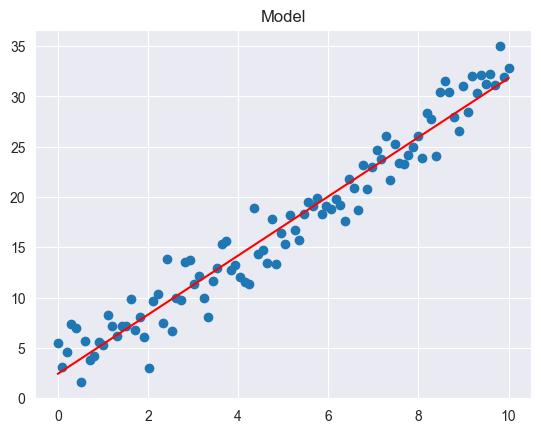

In [52]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from TMA_def import model_plot

np.random.seed(0)

n = 100
X = np.linspace(0, 10, n)
Y = 2 + 3 * X + np.random.normal(scale=2.0, size=n)

df = pd.DataFrame({"X": X, "Y": Y})

X_sm = sm.add_constant(df["X"])  # adds a column named "const"
model = sm.OLS(df["Y"], X_sm).fit()

model_plot(df['X'], Y, model)
print(model.summary())

RES = model.resid             # residuals (vector)
TSS = model.centered_tss      # total sum of squares (around mean)
ESS = model.ess               # explained sum of squares
RSS = model.ssr               # residual sum of squares
R2  = model.rsquared          # R-squared
RSE = model.resid.std(ddof=model.df_model + 1)

print(f"TSS = {TSS:.3f}, ESS = {ESS:.3f}, RSS = {RSS:.3f}, R2 = {R2:.3f}, RSE = {RSE:.3f}")

**Model:** $Y = \beta_0 + \beta_1 X + \varepsilon$

- $\beta_0$: intercept (value of $Y$ when $X = 0$)
- $\beta_1$: slope (change in $Y$ for unit change in $X$)
- $\varepsilon$: error term with $E(\varepsilon) = 0$, $\operatorname{Var}(\varepsilon) = \sigma^2$

**Least Squares Estimation:**
Minimize $\text{RSS} = \sum (y_i - \hat y_i)^2$ to find $\hat\beta_0$ and $\hat\beta_1$

**Key Quantities:**

- **TSS** (Total Sum of Squares) $= \sum (y_i - \bar y)^2$ (total variance in $Y$)
- **RSS** (Residual Sum of Squares) $= \sum (y_i - \hat y_i)^2$ (unexplained variance)
- **$R^2$** $= 1 - \text{RSS}/\text{TSS}$ (fraction of variance explained, $0 \le R^2 \le 1$)
- **RSE** $= \sqrt{\text{RSS}/(n - p - 1)}$ (residual standard error, estimate of $\sigma$)

### Multiple Linear Regression

In [53]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

# Example multiple linear regression with two predictors
np.random.seed(1)

n = 100
X1 = np.random.normal(size=n)
X2 = np.random.normal(size=n)

# True model: Y = 1 + 2*X1 - 1*X2 + noise
Y = 1 + 2 * X1 - 1 * X2 + np.random.normal(scale=1.0, size=n)

df = pd.DataFrame({"X1": X1, "X2": X2, "Y": Y})

X_sm = sm.add_constant(df[["X1", "X2"]])
model = sm.OLS(df["Y"], X_sm).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.770
Model:                            OLS   Adj. R-squared:                  0.766
Method:                 Least Squares   F-statistic:                     162.8
Date:                Wed, 28 Jan 2026   Prob (F-statistic):           1.01e-31
Time:                        19:11:29   Log-Likelihood:                -140.24
No. Observations:                 100   AIC:                             286.5
Df Residuals:                      97   BIC:                             294.3
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.9802      0.101      9.672      0.0

**Model:** $Y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \dots + \beta_p X_p + \varepsilon$

**Hypothesis Testing:**

**Individual t-test:** Test $H_0: \beta_j = 0$ vs $H_1: \beta_j \ne 0$

- Test statistic: $t = \hat\beta_j / \operatorname{SE}(\hat\beta_j) \sim t_{n-p-1}$
- Reject $H_0$ if $|t| > t_{1 - \alpha/2, df=n-p-1}$ or if p-value $< \alpha$
  - if $P > |t|$ is less than $\alpha$ (i.e. $0.05$): The parameter is significant, reject $H_0 := \beta_j = 0$
  - else if $P > |t|$ is greater than or equal $\alpha$ (i.e. $0.05$): Parameter _not_ significant, retain $H_0 := \beta_j = 0$

In [54]:
from scipy.stats import t

# the 97.5% quantile of a t-distribution with 18 degrees of freedom
t.ppf(0.975, df=18)

2.10092204024096

**Global F-test:** Test $H_0: \beta_1 = \beta_2 = \dots = \beta_p = 0$ (no predictors useful)

- $F = \dfrac{(\text{TSS} - \text{RSS})/p}{\text{RSS}/(n-p-1)} \sim F_{p,\,n-p-1}$
- If $H_0$ true, expect $F \approx 1$
- If $H_1$ true (at least one $\beta_j \ne 0$), expect $F > 1$
- Large $F$ and small p-value → reject $H_0$

**Partial F-test:** Test if subset of $q$ coefficients are zero

In [55]:
X_reduced = sm.add_constant(df[["X1"]])
model_reduced = sm.OLS(df["Y"], X_reduced).fit()

# The output gives the F statistic, its p-value,
# and the degrees of freedom difference between models:
f_stat, p_value, df_diff = model.compare_f_test(model_reduced)
f_stat, p_value, df_diff

(52.76773415397895, 9.481480727697889e-11, 1.0)



- $H_0: \beta_{p-q+1} = \dots = \beta_p = 0$ ($q$ coefficients)
- $F = \dfrac{(\text{RSS}_0 - \text{RSS})/q}{\text{RSS}/(n-p-1)} \sim F_{q,\,n-p-1}$
- $\text{RSS}_0$: smaller model (without $q$ predictors)
- RSS: larger model (with all predictors)

**Important Insight:** If all individual t-tests fail to reject but global F-test is significant → collinearity problem!

### Confidence vs. Prediction Intervals

In [56]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

np.random.seed(0)

n = 100
X = np.linspace(0, 10, n)
Y = 2 + 3 * X + np.random.normal(scale=2.0, size=n)

df = pd.DataFrame({"X": X, "Y": Y})

X_sm = sm.add_constant(df["X"])  # adds a column named "const"

model = sm.OLS(df["Y"], X_sm).fit()

# Predict at new point(s):
x0 = [5.0, 7.0]
x0_sm = sm.add_constant(x0, has_constant="add")
pred = model.get_prediction(x0_sm)

print("\nPrediction Summary (Intervals = 5%):\n", pred.summary_frame(alpha=0.05)) # 95% intervals
# mean                           := predicted response
# mean_se                        := predicted standard error
# [mean_ci_lower, mean_ci_upper] := confidence interval
# [obs_ci_lower, obs_ci_upper]   := prediction interval

print("\nConfidence Interval 5%:\n", pred.conf_int(alpha=0.05))


Prediction Summary (Intervals = 5%):
         mean   mean_se  mean_ci_lower  mean_ci_upper  obs_ci_lower  \
0  17.119616  0.202868      16.717031      17.522202     13.073682   
1  23.000685  0.246006      22.512494      23.488876     18.945338   

   obs_ci_upper  
0     21.165551  
1     27.056033  

Confidence Interval 5%:
 [[16.7170305  17.52220156]
 [22.51249409 23.48887648]]


**Confidence Interval:** For mean response $E(Y \mid X = x_0)$

- Estimates average $Y$ for given $X = x_0$
- Formula: $\hat y \pm t_{1 - \alpha/2, df=n-p-1} \times \operatorname{SE}(\hat y)$
- Narrower interval

**Prediction Interval:** For individual response $Y \mid X = x_0$

- Predicts single observation $Y$ for given $X = x_0$
- Formula: $\hat y \pm t_{1 - \alpha/2, df=n-p-1} \times \sqrt{\hat\sigma^2 + \operatorname{SE}^2(\hat y)}$
- Wider interval (includes both model uncertainty and $\sigma^2$)

**Which to use?**

- Mayor wants prognosis for his town → Prediction interval (single observation)
- Researcher wants average effect → Confidence interval (mean)

## Residual Analysis & Diagnostics

### Residual Plots

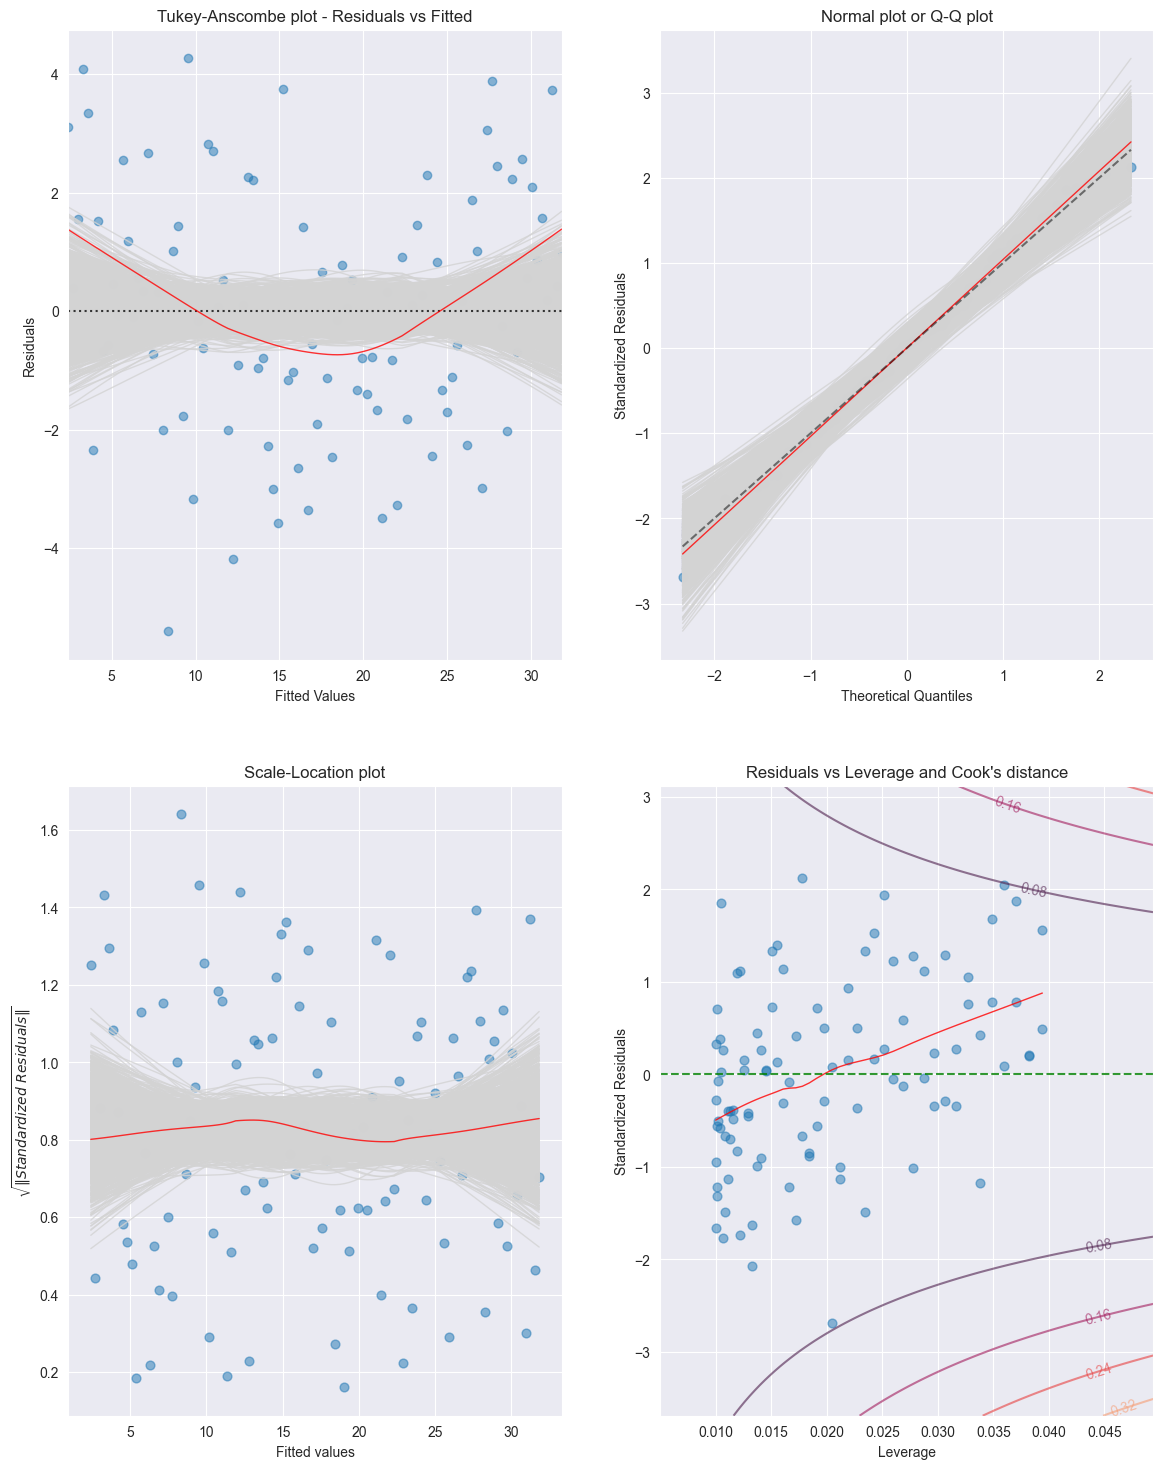

In [57]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from TMA_def import tma_plots

np.random.seed(0)

n = 100
X = np.linspace(0, 10, n)
Y = 2 + 3 * X + np.random.normal(scale=2.0, size=n)

df = pd.DataFrame({"X": X, "Y": Y})

X_sm = sm.add_constant(df["X"])  # adds a column named "const"

model = sm.OLS(df["Y"], X_sm).fit()

tma_plots(model)

**Tukey-Anscombe Plot (Residuals vs Fitted Values):**

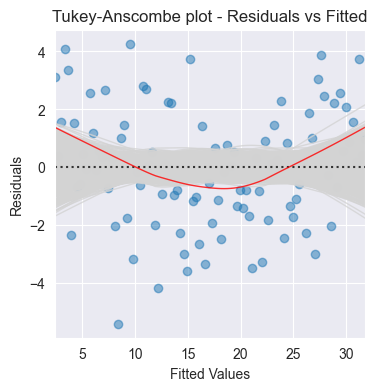

In [58]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from TMA_def import plot_residuals

np.random.seed(0)

n = 100
X = np.linspace(0, 10, n)
Y = 2 + 3 * X + np.random.normal(scale=2.0, size=n)

df = pd.DataFrame({"X": X, "Y": Y})

X_sm = sm.add_constant(df["X"])  # adds a column named "const"

model = sm.OLS(df["Y"], X_sm).fit()

fig = plt.figure(figsize = (4, 4))
ax = fig.add_subplot(1, 1, 1)
plot_residuals(ax, model.fittedvalues, model.resid, n_samp=1000, title='Tukey-Anscombe plot - Residuals vs Fitted')

- **What to look for:** Random scatter around zero
- **Patterns indicate problems:**
    - Curve/non-linear pattern → non-linearity (try polynomial or transformation)
    - Funnel shape → heteroscedasticity
    - Outliers → investigate data quality

**Scale-Location Plot** ($\sqrt{\lvert\text{standardized residuals}\rvert}$ vs fitted):

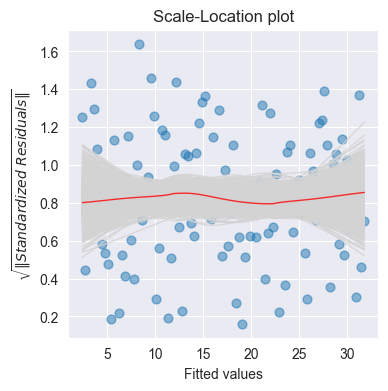

In [59]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from TMA_def import plot_scale_loc

np.random.seed(0)

n = 100
X = np.linspace(0, 10, n)
Y = 2 + 3 * X + np.random.normal(scale=2.0, size=n)

df = pd.DataFrame({"X": X, "Y": Y})

X_sm = sm.add_constant(df["X"])  # adds a column named "const"

model = sm.OLS(df["Y"], X_sm).fit()

fig = plt.figure(figsize = (4, 4))
ax = fig.add_subplot(1, 1, 1)
plot_scale_loc(ax, model.fittedvalues, np.sqrt(np.abs(model.get_influence().resid_studentized_internal)), n_samp=1000, x_lab='Fitted values')

- **Purpose:** Check homoscedasticity (constant variance)
- **Good:** Horizontal line with random scatter
- **Bad:** Increasing/decreasing trend → heteroscedasticity

**Normal Q-Q Plot:**

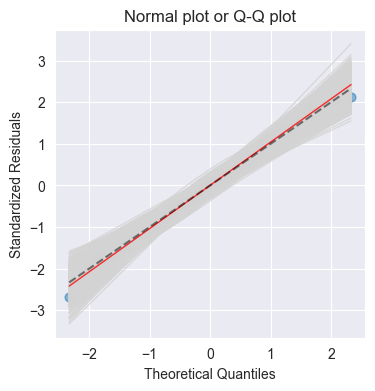

In [60]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from TMA_def import plot_QQ

np.random.seed(0)

n = 100
X = np.linspace(0, 10, n)
Y = 2 + 3 * X + np.random.normal(scale=2.0, size=n)

df = pd.DataFrame({"X": X, "Y": Y})

X_sm = sm.add_constant(df["X"])  # adds a column named "const"

model = sm.OLS(df["Y"], X_sm).fit()

fig = plt.figure(figsize = (4, 4))
ax = fig.add_subplot(1, 1, 1)
plot_QQ(ax, model.get_influence().resid_studentized_internal, n_samp=1000, title='Normal plot or Q-Q plot')

- **Purpose:** Check normality of residuals
- **Good:** Points follow diagonal line
- **Bad:** Deviations at tails → heavy-tailed/skewed distribution

**Residuals vs Leverage:**

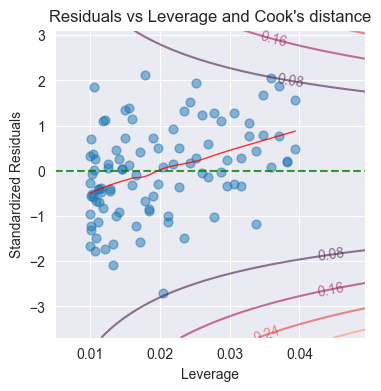

In [61]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from TMA_def import plot_cooks

np.random.seed(0)

n = 100
X = np.linspace(0, 10, n)
Y = 2 + 3 * X + np.random.normal(scale=2.0, size=n)

df = pd.DataFrame({"X": X, "Y": Y})

X_sm = sm.add_constant(df["X"])  # adds a column named "const"

model = sm.OLS(df["Y"], X_sm).fit()

res_inf = model.get_influence() # Influence of the Residuals
res_standard = res_inf.resid_studentized_internal # Studentized residuals using variance from OLS
res_inf_leverage = res_inf.hat_matrix_diag
x_min, x_max = min(res_inf_leverage) - 0.005, max(res_inf_leverage) + 0.01
y_min, y_max = min(res_standard) - 1, max(res_standard) + 1

fig = plt.figure(figsize = (4, 4))
ax = fig.add_subplot(1, 1, 1)
plot_cooks(ax, res_inf_leverage, res_standard, n_pred=1, x_lim=[x_min, x_max], y_lim=[y_min, y_max])



- **Purpose:** Identify influential observations
- Shows Cook’s distance contours
- Points outside Cook’s $D = 0.5$ or $1.0$ are influential


### Influential Points

**Leverage ($h_i$):**

- Measures how far predictor values $x_i$ are from $\bar x$
- High leverage: $h_i > 2(p+1)/n$
- High leverage doesn’t mean influential!

**Cook’s Distance ($D_i$):**

- Measures influence of observation $i$ on fitted values
- Combines leverage and residual size
- **Problematic:** $D_i > 0.5$ or $D_i > 1$
- Influential points have high Cook’s $D$

**Standardized Residuals:**

- $r_i = \dfrac{e_i}{\hat\sigma \sqrt{1-h_i}}$
- **Outlier if:** $\lvert r_i\rvert > 2$ (or $> 3$ for stricter criterion)

**Decision Tree:**

- High leverage + large residual → influential (investigate!)
- High leverage + small residual → not influential (okay)
- Low leverage + large residual → outlier but not influential
- Low leverage + small residual → typical observation

### Collinearity

**Definition:** Predictor variables are highly correlated

**Variance Inflation Factor (VIF):**

In [62]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

np.random.seed(1)

n = 100
X1 = np.random.normal(size=n)
X2 = np.random.normal(size=n)
Y = 1 + 2 * X1 - 1 * X2 + np.random.normal(scale=1.0, size=n)
df = pd.DataFrame({"X1": X1, "X2": X2, "Y": Y})

X_vif = sm.add_constant(df[["X1", "X2"]])

vif_data = []
for j, col in enumerate(X_vif.columns):
    vif = variance_inflation_factor(X_vif.values, j)
    vif_data.append((col, vif))

vif_data

[('const', 1.0297726694375249),
 ('X1', 1.0082820653058149),
 ('X2', 1.0082820653058144)]

- $\text{VIF}_j = \dfrac{1}{1 - R_j^2}$
- $R_j^2$ from regression of $X_j$ on all other predictors

**Interpretation:**

- $\text{VIF} = 1$: no collinearity
- $\text{VIF} > 5$: moderate collinearity
- $\text{VIF} > 10$: severe collinearity (problematic!)

**Effects of Collinearity:**

- Inflates standard errors of coefficients
- Makes coefficients unstable (sensitive to data changes)
- Reduces statistical power (harder to reject $H_0$)
- Difficult to interpret individual coefficients
- Does NOT reduce $R^2$ or predictive accuracy!

**Solutions:**

- Remove correlated predictors
- Combine correlated predictors (e.g., average)
- Use ridge regression or lasso
- Increase sample size
- Variable transformation (e.g., center variables)

## Qualitative Predictors & Interactions

### Dummy Variables (Categorical Predictors)

In [63]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

np.random.seed(123)

# Create categorical predictor with 3 levels
n = 150
X = np.random.choice(["African American", "Asian", "Caucasian"], size=n, p=[0.4, 0.3, 0.3])

# True means: African American ~ 50, Asian ~ 55, Caucasian ~ 52 (all with sd 3)
means = { "African American": 50, "Asian": 55, "Caucasian": 52 }
Y = np.array([np.random.normal(loc=means[x], scale=3.0) for x in X])

df = pd.DataFrame({"ethnicity": X, "Y": Y})

# Automatically create k-1 dummies with get_dummies (drop_first=True)
X_dummy = pd.get_dummies(df["ethnicity"], drop_first=True, dtype=float)
X_dummy = sm.add_constant(X_dummy)
print(X_dummy.head())

model = sm.OLS(df["Y"], X_dummy).fit()
print(model.summary())

   const  Asian  Caucasian
0    1.0    1.0        0.0
1    1.0    0.0        0.0
2    1.0    0.0        0.0
3    1.0    1.0        0.0
4    1.0    0.0        1.0
                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.368
Model:                            OLS   Adj. R-squared:                  0.359
Method:                 Least Squares   F-statistic:                     42.77
Date:                Wed, 28 Jan 2026   Prob (F-statistic):           2.29e-15
Time:                        19:11:43   Log-Likelihood:                -363.41
No. Observations:                 150   AIC:                             732.8
Df Residuals:                     147   BIC:                             741.9
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t     

**Two Levels (e.g., Gender: Male/Female):**

- Create one dummy variable: $X = 1$ if Female, $X = 0$ if Male
- Model: $Y = \beta_0 + \beta_1 X + \varepsilon$
- **Interpretation:**
    - $\beta_0$: mean for males (baseline)
    - $\beta_0 + \beta_1$: mean for females
    - $\beta_1$: difference between females and males
- Test $H_0: \beta_1 = 0$ tests if gender matters

**Three Levels (e.g., Ethnicity: Asian, Caucasian, African American):**

- Create **two** dummy variables ($k$ levels → $k-1$ dummies):
    - $X_1 = 1$ if Asian, $0$ otherwise
    - $X_2 = 1$ if Caucasian, $0$ otherwise
    - African American is baseline (both $X_1 = 0$, $X_2 = 0$)
- Model: $Y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \varepsilon$
- **Interpretation:**
    - $\beta_0$: mean for African Americans (baseline)
    - $\beta_0 + \beta_1$: mean for Asians
    - $\beta_0 + \beta_2$: mean for Caucasians
    - $\beta_1$: difference between Asian and African American
    - $\beta_2$: difference between Caucasian and African American

**Key Rule:** For $k$ categories, need $k-1$ dummy variables (one category is baseline)

**Baseline Choice:** Arbitrary, doesn’t affect model fit, only interpretation

### Interaction Effects

**Model with Interaction:**

$Y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \beta_3 X_1 X_2 + \varepsilon$

**When $\beta_3 \ne 0$:** Effect of $X_1$ on $Y$ depends on value of $X_2$ (synergy/interaction)

In [64]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

np.random.seed(123)

n = 200
X1 = np.random.uniform(0, 10, size=n)
X2 = np.random.uniform(0, 5, size=n)

beta0_true = 1.0
beta1_true = 2.0
beta2_true = 1.0
beta3_true = 0.5

noise = np.random.normal(scale=2.0, size=n)
Y = beta0_true + beta1_true * X1 + beta2_true * X2 + beta3_true * X1 * X2 + noise

df = pd.DataFrame({"X1": X1, "X2": X2, "Y": Y})

# Y = beta0 + b1*X1 + b2*X2 + b3*X1*X2
X = sm.add_constant(df[["X1", "X2"]])
X["X1*X2"] = df["X1"] * df["X2"]

model = sm.OLS(df["Y"], X).fit()
print(model.summary())

# To assess significance of X1*X2 in the output:
# Because P>|t| = 0.000 (is less than 5%) and the
# CI [0.438, 0.585] does not contain 0, the interaction term
# is significant.

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.964
Model:                            OLS   Adj. R-squared:                  0.963
Method:                 Least Squares   F-statistic:                     1750.
Date:                Wed, 28 Jan 2026   Prob (F-statistic):          3.46e-141
Time:                        19:11:43   Log-Likelihood:                -417.85
No. Observations:                 200   AIC:                             843.7
Df Residuals:                     196   BIC:                             856.9
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.7644      0.594      1.287      0.2

**Rewrite to see interaction:**
$Y = (\beta_0 + \beta_2 X_2) + (\beta_1 + \beta_3 X_2) X_1$

- Intercept for $X_1$: $\beta_0 + \beta_2 X_2$ (changes with $X_2$)
- Slope for $X_1$: $\beta_1 + \beta_3 X_2$ (changes with $X_2$)

**Example (Advertising):**
$\text{Sales} = \beta_0 + \beta_1 \cdot \text{TV} + \beta_2 \cdot \text{Radio} + \beta_3 \cdot (\text{TV} \times \text{Radio})$

- $\beta_3 > 0$: spending on TV increases effectiveness of Radio (and vice versa)
- Interaction means: 50/50 split between TV and Radio is better than all on one

**Hierarchical Principle:**
If interaction $X_1 X_2$ is significant, **must include** both main effects $X_1$ and $X_2$ in model, even if they’re not individually significant


### Polynomial Regression

**Model:** $Y = \beta_0 + \beta_1 X + \beta_2 X^2 + \dots + \beta_p X^p + \varepsilon$

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.688
Model:                            OLS   Adj. R-squared:                  0.686
Method:                 Least Squares   F-statistic:                     428.0
Date:                Wed, 28 Jan 2026   Prob (F-statistic):           5.40e-99
Time:                        19:11:43   Log-Likelihood:                -1133.2
No. Observations:                 392   AIC:                             2272.
Df Residuals:                     389   BIC:                             2284.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           56.9001      1.800     31.604   

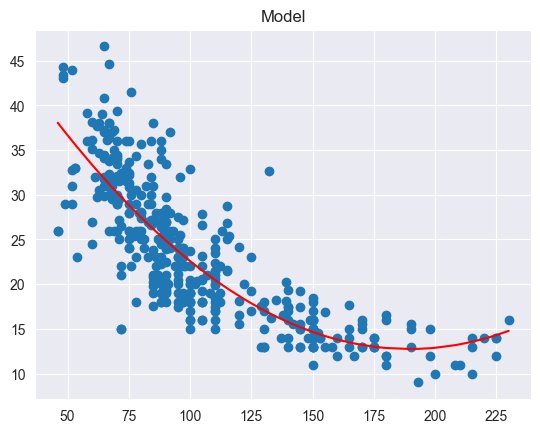

In [65]:
import pandas as pd
import statsmodels.api as sm
from TMA_def import model_plot

df = pd.read_csv('predictive-modeling/Auto.csv')
X = pd.DataFrame({ 'horsepower' : df['horsepower'], 'horsepower^2' : (df['horsepower'] * df['horsepower'])})
Y = df['mpg']

X_sm = sm.add_constant(X)
model = sm.OLS(Y, X_sm).fit()
print(model.summary())

model_plot(df['horsepower'], df['mpg'], model)



**Key Points:**

- Used when relationship between $X$ and $Y$ is non-linear
- Still a linear model (linear in parameters $\beta$!)
- Can fit using standard least squares
- Degree $p$ determined by:
    - Residual plots (check if pattern remains)
    - Cross-validation
    - Hypothesis tests (is $\beta_p$ significant?)

**Example:** $\text{mpg} = \beta_0 + \beta_1 \cdot \text{horsepower} + \beta_2 \cdot \text{horsepower}^2$ captures non-linear relationship

**Warning:** High-degree polynomials can overfit!

## Model Selection

### Variable Selection Methods

**Best Subset Selection:**

- Fit all $2^p$ possible models (with $0,1,2,\dots,p$ predictors)
- For each size $k$, choose best model (lowest RSS or highest $R^2$)
- Select single best model using criterion (AIC, BIC, adj-$R^2$, $C_p$)
- **Problem:** Computationally infeasible for $p > 40$



**BIC and AIC Scorers for Linear Regression Model Selection**

In [66]:
from statsmodels.tools.eval_measures import aic as sm_aic, bic as sm_bic

def aic_scorer(estimator, X, y):
    """
    Compute AIC for linear regression model.
    Returns negative AIC.
    """
    y_pred = estimator.predict(X)
    n = len(y) # number of observations
    k = X.shape[1] + 1  # number of parameters (features + intercept)

    res = y - y_pred
    rss = np.sum(res ** 2)

    # Log-likelihood for !!linear regression!!
    llf = -0.5 * n * (np.log(rss / n) + np.log(2 * np.pi))

    return sm_aic(llf, n, k) * -1 # because we want to maximize

def bic_scorer(estimator, X, y):
    """
    Compute BIC for linear regression model.
    Returns negative BIC (loss function).
    """
    y_pred = estimator.predict(X)
    n = len(y)  # number of observations
    k = X.shape[1] + 1  # number of parameters (features + intercept)

    res = y - y_pred
    rss = np.sum(res ** 2)

    # Log-likelihood for linear regression
    llf = -0.5 * n * (np.log(rss / n) + np.log(2 * np.pi))

    return sm_bic(llf, n, k) * -1  # because we want to maximize

**Forward Stepwise Selection:**

In [67]:
import pandas as pd
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LinearRegression

df = pd.read_csv('predictive-modeling/Credit.csv')
df = pd.get_dummies(data=df, drop_first=True, dtype=float)

X = df.drop(columns='Balance')
y = df['Balance']

model = LinearRegression()
sfs = SequentialFeatureSelector(
    model,
    direction="forward",   # or "backward"
    n_features_to_select="auto",  # or a number
    # Estimators have a score method providing a default evaluation criterion
    # for the problem they are designed to solve. Most commonly this is
    # accuracy for classifiers and R^2 for regressors.
    # https://scikit-learn.org/stable/modules/model_evaluation.html#scoring-api-overview
    #
    # You can use default (=None), create your own (see aic_scorer or bic_scorer), or builtin:
    # https://scikit-learn.org/stable/modules/model_evaluation.html#string-name-scorers
    scoring=aic_scorer,
)
sfs.fit(X, y)

mask = sfs.get_support()
features = X.columns[mask]
features

Index(['Income', 'Limit', 'Rating', 'Cards', 'Age', 'Student_Yes'], dtype='object')

1. Start with $M_0$ (null model: only intercept)
2. For $k = 0,1,\dots,p-1$:
    - Add one predictor that most improves fit (lowest RSS)
    - Result: $M_{k+1}$
3. Select single best model from $M_0, M_1, \dots, M_p$ using criterion

- **Advantage:** Only $p(p+1)/2 + 1$ models (computationally efficient)
- Greedy algorithm (may miss best overall model)

**Backward Stepwise Selection:**

In [68]:
import pandas as pd
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LinearRegression

df = pd.read_csv('predictive-modeling/Credit.csv')
df = pd.get_dummies(data=df, drop_first=True, dtype=float)

X = df.drop(columns='Balance')
y = df['Balance']

model = LinearRegression()
sfs = SequentialFeatureSelector(
    model,
    direction="backward",   # or "forward"
    n_features_to_select="auto",  # or a number
    # Estimators have a score method providing a default evaluation criterion
    # for the problem they are designed to solve. Most commonly this is
    # accuracy for classifiers and R^2 for regressors.
    # https://scikit-learn.org/stable/modules/model_evaluation.html#scoring-api-overview
    #
    # You can use default (=None), create your own (see aic_scorer or bic_scorer), or builtin:
    # https://scikit-learn.org/stable/modules/model_evaluation.html#string-name-scorers
    scoring=aic_scorer,
)
sfs.fit(X, y)

mask = sfs.get_support()
features = X.columns[mask]
features

Index(['Income', 'Limit', 'Rating', 'Cards', 'Age', 'Student_Yes'], dtype='object')

1. Start with $M_p$ (full model: all predictors)
2. For $k = p,p-1,\dots,1$:
    - Remove predictor whose removal least hurts fit
    - Result: $M_{k-1}$
3. Select single best model using criterion

- **Advantage:** Only $p(p+1)/2 + 1$ models
- **Limitation:** Requires $n > p$

**Hybrid Stepwise Selection:**

- Alternates between adding and removing variables
- Can correct for earlier mistakes
- Similar computational efficiency to forward/backward

### Model Selection Criteria

**Goal:** Balance fit vs. complexity (avoid overfitting)

In [69]:
import statsmodels.api as sm
import pandas as pd

df = pd.read_csv('predictive-modeling/Credit.csv')

def fit_model(predictors):
    X = sm.add_constant(df[predictors])
    y = df["Balance"]
    model = sm.OLS(y, X).fit()
    return model

M1 = fit_model(["Income"])
M2 = fit_model(["Income", "Limit"])
M3 = fit_model(["Income", "Limit", "Rating"])
M4 = fit_model(["Income", "Limit", "Rating", "Cards"])

models = {"M1": M1, "M2": M2, "M3": M3, "M4": M4}

**Adjusted $R^2$ → Select model that maximizes adj-$R^2$:**

In [70]:
for name, model in models.items():
    print(name, "adj_R2 =", model.rsquared_adj)

M1 adj_R2 = 0.21300489131364186
M2 adj_R2 = 0.8704575713334397
M3 adj_R2 = 0.8753013618810308
M4 adj_R2 = 0.8757468863485864


- Formula: $\text{adj-}R^2 = 1 - \dfrac{\text{RSS}/(n-p-1)}{\text{TSS}/(n-1)}$
- Regular $R^2$ always increases with more predictors
- Adjusted $R^2$ penalizes adding predictors

**AIC (Akaike Information Criterion) → Select model that minimizes AIC:**

In [71]:
for name, model in models.items():
    print(name, "AIC =", model.aic)

M1 AIC = 5945.89424951724
M2 AIC = 5225.202531162302
M3 AIC = 5210.950291148072
M4 AIC = 5210.507229752486


- For least squares: $\text{AIC} = \dfrac{1}{n \hat\sigma^2} \text{RSS} + 2(p+1)$
- General form: $\text{AIC} = -2 \log(L) + 2q$
    - $L$: likelihood, $q$: number of parameters
- Penalty term: $2(p+1)$ increases with more predictors

**BIC (Bayesian Information Criterion) → Select model that minimizes BIC:**

In [72]:
for name, model in models.items():
    print(name, "BIC =", model.bic)

M1 BIC = 5953.877178611456
M2 BIC = 5237.176924803626
M3 BIC = 5226.9161493365045
M4 BIC = 5230.464552488025


- **Tends to select smaller models than AIC**
- For least squares: $\text{BIC} = \dfrac{1}{n \hat\sigma^2} \text{RSS} + \log(n)(p+1)$
- General form: $\text{BIC} = -2 \log(L) + \log(n) q$
- Penalty term: $\log(n)(p+1)$ stronger than AIC for $n > 7$

**Mallows’ $C_p$ → Select model that minimizes $C_p$:**

In [73]:
import numpy as np

def mallows_cp(model_candidate, model_full):
    """
    Mallows Cp using slide formula:
        Cp = (1/n) * (RSS_m + 2 * p * sigma_hat^2_full)
    model_candidate: statsmodels OLSResults for the subset model
    model_full:      statsmodels OLSResults for the largest model
    """
    n = model_candidate.nobs # number of observations
    RSS_m = np.sum(model_candidate.resid**2) # residual sum of squares of the candidate model

    # p = number of parameters in candidate model (including intercept)
    p = int(model_candidate.df_model) + 1

    sigma2_full = model_full.mse_resid  # estimate of the error variance σ̂² from full model

    Cp = (RSS_m + 2 * p * sigma2_full) / n
    return Cp

print(f"M1 Cp = {mallows_cp(M1, M4)}")
print(f"M2 Cp = {mallows_cp(M2, M4)}")
print(f"M3 Cp = {mallows_cp(M3, M4)}")
print(f"M4 Cp = {mallows_cp(M4, M4)}")

M1 Cp = 165784.50530352452
M2 Cp = 27571.04635232112
M3 Cp = 26620.27911254733
M4 Cp = 26592.707689604606


- Formula: $C_{p} = \frac{1}{n} \left( \mathrm{RSS} + 2p\hat{\sigma}^{2} \right)$
- Proportional to AIC for least squares

**Key Insight:**

- All criteria balance fit (RSS) vs. complexity ($p$)
- AIC: prediction-focused
- BIC: explanation-focused, stronger penalty → simpler models
- For large $n$, BIC ≈ AIC with stronger penalty

## Regularization Methods

### Ridge Regression

**Objective Function:**
Minimize $\text{RSS} + \lambda \sum_{j=1}^p \beta_j^2$

In [74]:
###################
# Ridge Regression
###################

import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

df = pd.read_csv('predictive-modeling/Credit.csv', index_col="Unnamed: 0")
df = pd.get_dummies(data=df, drop_first=True, dtype=float)

X = df.drop(columns='Balance')
# Standardize predictors (Ridge is scale-sensitive)
X = pd.DataFrame(StandardScaler().fit_transform(X), columns=X.columns, index=X.index)
y = df['Balance']

# Fit model:
lambda_ridge = 100
ridge = Ridge(alpha=lambda_ridge) # alpha = lambda
ridge.fit(X, y)

print(
    f"Ridge coefficients (λ = {lambda_ridge}):\n",
    pd.DataFrame({ "Predictor": ["**Intercept**"] + list(X.columns), "Ridge Coefficient": [ridge.intercept_] + list(ridge.coef_)})
)

#########################################
# Ridge with Cross-Validation to choose λ
#########################################

import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV

df = pd.read_csv('predictive-modeling/Credit.csv', index_col="Unnamed: 0")
df = pd.get_dummies(data=df, drop_first=True, dtype=float)

X = df.drop(columns='Balance')
# Standardize predictors (Ridge is scale-sensitive)
X = pd.DataFrame(StandardScaler().fit_transform(X), columns=X.columns, index=X.index)
y = df['Balance']

# Grid of λ values to try
alphas = np.logspace(-2, 4, 50)  # 10^-2 to 10^4
ridge_cv = RidgeCV(alphas=alphas, cv=10)
ridge_cv.fit(X, y)

print(
    f"Ridge coefficients (Cross Validation selected λ = {ridge_cv.alpha_}):\n",
    pd.DataFrame({ "Predictor": ["**Intercept**"] + list(X.columns), "Ridge Coefficient": [ridge.intercept_] + list(ridge.coef_)})
)

Ridge coefficients (λ = 100):
               Predictor  Ridge Coefficient
0         **Intercept**         520.015000
1                Income         -94.597784
2                 Limit         211.391442
3                Rating         209.601376
4                 Cards          22.356504
5                   Age         -19.035029
6             Education          -0.423652
7         Gender_Female           0.179193
8           Student_Yes          97.638749
9           Married_Yes          -6.011495
10      Ethnicity_Asian           3.512579
11  Ethnicity_Caucasian           3.544476
Ridge coefficients (Cross Validation selected λ = 0.517947467923121):
               Predictor  Ridge Coefficient
0         **Intercept**         520.015000
1                Income         -94.597784
2                 Limit         211.391442
3                Rating         209.601376
4                 Cards          22.356504
5                   Age         -19.035029
6             Education          -0.42

**Components:**

- RSS: want good fit
- $\lambda \sum \beta_j^2$: $L_2$ penalty (shrinkage penalty)
- $\lambda \ge 0$: tuning parameter

**Behavior:**

- $\lambda = 0$ → ordinary least squares (no penalty)
- $\lambda \to \infty$ → all $\beta_j \to 0$ (maximum shrinkage)
- Intermediate $\lambda$: balance fit and shrinkage

**Properties:**

- Shrinks coefficients toward zero
- Does **NOT** set coefficients exactly to zero
- All $p$ predictors remain in final model
- Reduces variance at cost of increased bias
- Helps with collinearity (stabilizes coefficients)

**Equivalent Constrained Form:**
Minimize RSS subject to $\sum \beta_j^2 \le s$

- Larger $s$ (or smaller $\lambda$) → less shrinkage

**Why standardize?**

- Ridge penalty depends on scale of predictors
- **Always standardize** predictors before applying ridge

### Lasso Regression

**Objective Function:**
Minimize $\text{RSS} + \lambda \sum_{j=1}^p |\beta_j|$

In [75]:
##################
# Lasso Regression
##################

import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso

df = pd.read_csv('predictive-modeling/Credit.csv', index_col="Unnamed: 0")
df = pd.get_dummies(data=df, drop_first=True, dtype=float)

X = df.drop(columns='Balance')
# Standardize predictors (Lasso is scale-sensitive)
X = pd.DataFrame(StandardScaler().fit_transform(X), columns=X.columns, index=X.index)
y = df['Balance']

# Fit model:
lambda_lasso = 0.5
lasso = Lasso(alpha=lambda_lasso, max_iter=10000) # alpha = lambda
lasso.fit(X, y)

print(
    f"Lasso coefficients (λ = {lambda_lasso}):\n",
    pd.DataFrame({ "Predictor": ["**Intercept**"] + list(X.columns), "Lasso Coefficient": [lasso.intercept_] + list(lasso.coef_)})
)

#########################################
# Lasso with Cross-Validation to choose λ
#########################################

import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV

df = pd.read_csv('predictive-modeling/Credit.csv', index_col="Unnamed: 0")
df = pd.get_dummies(data=df, drop_first=True, dtype=float)

X = df.drop(columns='Balance')
# Standardize predictors (Lasso is scale-sensitive)
X = pd.DataFrame(StandardScaler().fit_transform(X), columns=X.columns, index=X.index)
y = df['Balance']

alphas_lasso = np.logspace(-3, 1, 50)

lasso_cv = LassoCV(alphas=alphas_lasso, cv=10, max_iter=10000, random_state=0)
lasso_cv.fit(X, y)

print(
    f"Lasso coefficients (Cross Validation selected λ = {lasso_cv.alpha_}):\n",
    pd.DataFrame({ "Predictor": ["**Intercept**"] + list(X.columns), "Lasso Coefficient": [lasso_cv.intercept_] + list(lasso_cv.coef_)})
)

Lasso coefficients (λ = 0.5):
               Predictor  Lasso Coefficient
0         **Intercept**         520.015000
1                Income        -272.379767
2                 Limit         445.239368
3                Rating         168.100954
4                 Cards          24.180697
5                   Age         -10.270095
6             Education          -2.974457
7         Gender_Female          -4.738478
8           Student_Yes         127.195235
9           Married_Yes          -3.541359
10      Ethnicity_Asian           6.012987
11  Ethnicity_Caucasian           3.833064
Lasso coefficients (Cross Validation selected λ = 0.2329951810515372):
               Predictor  Lasso Coefficient
0         **Intercept**         520.015000
1                Income        -273.615943
2                 Limit         448.113594
3                Rating         166.512475
4                 Cards          24.471506
5                   Age         -10.427643
6             Education          -3.2

**Components:**

- RSS: want good fit
- $\lambda \sum |\beta_j|$: $L_1$ penalty
- $\lambda \ge 0$: tuning parameter

**Properties:**

- Shrinks coefficients toward zero
- **Sets some coefficients exactly to zero** (automatic variable selection!)
- Produces sparse models (only subset of predictors)
- More interpretable than ridge
- Also helps with collinearity

**Equivalent Constrained Form:**
Minimize RSS subject to $\sum |\beta_j| \le s$

**Why Lasso Produces Sparse Solutions:**

- $L_1$ constraint region has corners (diamond shape in 2D)
- RSS contours (ellipses) often intersect constraint at corners
- At corners, some coefficients are exactly zero
- Ridge has circular constraint (no corners) → no exact zeros


### Comparing Ridge and Lasso

|  | Ridge | Lasso                           |
| :-- | :-- |:--------------------------------|
| Penalty | $L_2$: $\sum \beta_j^2$ | $L_1$: $\sum \mid \beta_j \mid$ |
| Exact zeros? | No | Yes                             |
| Variable selection? | No | Yes                             |
| All predictors included? | Yes | No (sparse)                     |
| Interpretability | Lower | Higher                          |
| When to use | Many predictors, all relevant | Many predictors, few relevant   |

**Bias-Variance Trade-Off:**

- Both reduce variance by introducing bias
- As $\lambda$ increases: variance ↓, bias ↑
- Optimal $\lambda$ minimizes test MSE


### Selecting Tuning Parameter $\lambda$

**Method: Cross-Validation**

1. Choose grid of $\lambda$ values (e.g., $10^{-2}$ to $10^6$)
2. For each $\lambda$:
    - Perform $k$-fold CV
    - Compute CV error (MSE for regression)
3. Select $\lambda$ that minimizes CV error
4. Refit model on full training data with chosen $\lambda$

**Typical Result:**

- $\lambda$ too small → overfitting (high variance, acts like OLS)
- $\lambda$ too large → underfitting (high bias, coefficients too small)
- Optimal $\lambda$ in middle

## Logistic Regression

### Simple Logistic Regression

**Goal:** Model probability $P(Y = 1 \mid X)$ where $Y$ is binary (0 or 1)

**Logistic Function:**
$p(x) = P(Y = 1 \mid X = x) = \dfrac{e^{\beta_0 + \beta_1 x}}{1 + e^{\beta_0 + \beta_1 x}}$

In [76]:
import pandas as pd
import statsmodels.api as sm

df = pd.read_csv('predictive-modeling/Default.csv', sep=';')
df = df.join(pd.get_dummies(df['default'], prefix='default', drop_first=True, dtype=float))

x = df['balance']
y = df['default_Yes']

x_sm = sm.add_constant(x)

model = sm.GLM(y, x_sm, family=sm.families.Binomial()).fit()
# or: model = sm.Logit(y, x_sm).fit()

print(model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:            default_Yes   No. Observations:                10000
Model:                            GLM   Df Residuals:                     9998
Model Family:                Binomial   Df Model:                            1
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -798.23
Date:                Wed, 28 Jan 2026   Deviance:                       1596.5
Time:                        19:11:44   Pearson chi2:                 7.15e+03
No. Iterations:                     9   Pseudo R-squ. (CS):             0.1240
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        -10.6513      0.361    -29.491      0.0

**Properties:**

- Output always between 0 and 1 (valid probability)
- S-shaped curve
- Linear relationship in log-odds scale

**Odds:**
$\operatorname{odds}(x) = \dfrac{p(x)}{1 - p(x)} = e^{\beta_0 + \beta_1 x}$

- Odds = 1: equal probability (50-50)
- Odds $> 1$: more likely is $p(x)$
- Odds $< 1$: more likely is $1 - p(x)$

**Log-Odds (Logit):**
$\log\left(\dfrac{p(x)}{1 - p(x)}\right) = \beta_0 + \beta_1 x$

- **Linear in $x$!**
- This is why it’s called “logistic regression”

**Interpretation of Coefficients:**

- $\beta_1$: change in log-odds for 1-unit increase in $X$
- Unit increase in $X$ → odds multiply by $e^{\beta_1}$
- $\beta_1 > 0$: positive association ($X \uparrow \Rightarrow P(Y=1) \uparrow$)
- $\beta_1 < 0$: negative association ($X \uparrow \Rightarrow P(Y=1) \downarrow$)

**Estimation:**

- Use Maximum Likelihood (not least squares!)
- No closed-form solution, requires numerical optimization

**Example Calculation:**
If $\beta_0 = -10.65$, $\beta_1 = 0.0055$, $X = 1000$:

- log-odds $= -10.65 + 0.0055 \cdot 1000 = -5.15$
- odds $= e^{-5.15} \approx 0.0058$
- $p = 0.0058/(1 + 0.0058) \approx 0.0058$

### Multiple Logistic Regression

**Model:**
$P(Y = 1 \mid X_1, \dots, X_p) = \dfrac{e^{\beta_0 + \beta_1 X_1 + \dots + \beta_p X_p}}{1 + e^{\beta_0 + \beta_1 X_1 + \dots + \beta_p X_p}}$

**Log-odds:**
$\log\left(\dfrac{p}{1-p}\right) = \beta_0 + \beta_1 X_1 + \dots + \beta_p X_p$

In [77]:
import pandas as pd
import statsmodels.api as sm

df = pd.read_csv('predictive-modeling/Default.csv', sep=';')
df = pd.get_dummies(data=df, drop_first=True, dtype=float)

X = df[['balance', 'income']]
y = df['default_Yes']

X_sm = sm.add_constant(X)
model = sm.GLM(y, X_sm, family=sm.families.Binomial()).fit()
# or: model = sm.Logit(y, X_sm).fit()

print(model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:            default_Yes   No. Observations:                10000
Model:                            GLM   Df Residuals:                     9997
Model Family:                Binomial   Df Model:                            2
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -789.48
Date:                Wed, 28 Jan 2026   Deviance:                       1579.0
Time:                        19:11:44   Pearson chi2:                 6.95e+03
No. Iterations:                     9   Pseudo R-squ. (CS):             0.1256
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        -11.5405      0.435    -26.544      0.0

**Interpretation:**

- $\beta_j$: change in log-odds when $X_j$ increases by 1, holding other $X_j$ constant
- Holding others constant, odds multiply by $e^{\beta_j}$




### Classification \& Model Evaluation

**Classification Rule:**

- If $p(x) \ge$ threshold (typically $0.5$) → predict $Y = 1$
- If $p(x) <$ threshold → predict $Y = 0$

**Confusion Matrix:**

In [78]:
from sklearn.metrics import confusion_matrix

threshold = 0.5
y_pred = model.predict(X_sm)
y_pred = (y_pred >= threshold).astype(int)

print(confusion_matrix(y, y_pred))

tn, fp, fn, tp = confusion_matrix(y, y_pred).ravel()
total = tn + fp + fn + tp
print(f"TN = {tn}, FP = {fp}, FN = {fn}, TP = {tp}, Total = {total}")

[[9629   38]
 [ 225  108]]
TN = 9629, FP = 38, FN = 225, TP = 108, Total = 10000


```text
                Predicted Class
              0           1
Actual  0    TN          FP    (Total N)
        1    FN          TP    (Total P)
```

- TP (True Positive): correctly predicted 1
- TN (True Negative): correctly predicted 0
- FP (False Positive): predicted 1, actually 0 (Type I error)
- FN (False Negative): predicted 0, actually 1 (Type II error)



**Performance Metrics:**

In [79]:
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

threshold = 0.5
y_pred = model.predict(X_sm)
y_pred = (y_pred >= threshold).astype(int)

print(classification_report(y, y_pred))
# macro average: Simple average of precision, recall and f1-score across all classes (treats each class equally).
# weighted average: Average weighted by the number of samples in each class (accounts for class imbalance).

print(f"Accuracy Score:\t\t{accuracy_score(y, y_pred):.3f}")
print(f"Precision Score:\t{precision_score(y, y_pred):.3f}")
print(f"Recall Score:\t\t{recall_score(y, y_pred):.3f}")
# Specificity is just recall of the negative class (pos_label=0)
print(f"Specificity Score:\t{recall_score(y, y_pred, pos_label=0):.3f}")
print(f"F1-Score:\t\t\t{f1_score(y, y_pred):.3f}")

              precision    recall  f1-score   support

         0.0       0.98      1.00      0.99      9667
         1.0       0.74      0.32      0.45       333

    accuracy                           0.97     10000
   macro avg       0.86      0.66      0.72     10000
weighted avg       0.97      0.97      0.97     10000

Accuracy Score:		0.974
Precision Score:	0.740
Recall Score:		0.324
Specificity Score:	0.996
F1-Score:			0.451


**Accuracy** $= \dfrac{\text{TP} + \text{TN}}{\text{Total}}$

- Proportion of correct predictions
- **Problem:** Misleading with class imbalance!

**Precision** $= \dfrac{\text{TP}}{\text{TP} + \text{FP}}$

- Among predicted positives, what fraction are correct?
- High precision: few false alarms

**Recall (Sensitivity, True Positive Rate)** $= \dfrac{\text{TP}}{\text{TP} + \text{FN}}$

- Among actual positives, what fraction did we detect?
- High recall: catch most positives

**Specificity (True Negative Rate)** $= \dfrac{\text{TN}}{\text{TN} + \text{FP}}$

- Among actual negatives, what fraction did we correctly identify?

**F1 Score** $= 2 \times \dfrac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$

- Harmonic mean of precision and recall
- Balances both metrics
- Good for imbalanced classes

**False Positive Rate** $= \dfrac{\text{FP}}{\text{FP} + \text{TN}} = 1 - \text{Specificity}$

**Classification Error** $= \dfrac{\text{FP} + \text{FN}}{\text{Total}} = 1 - \text{Accuracy}$

### Receiver Operating Characteristic (ROC) Curve

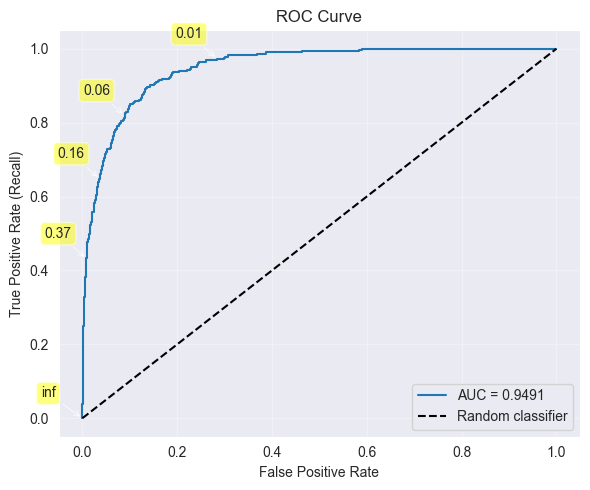

i = 228:	Threshold = 0.1299, True Positive Rate = 0.7027, False Positive Rate: 0.05
i = 229:	Threshold = 0.1268, True Positive Rate = 0.7027, False Positive Rate: 0.05
i = 230:	Threshold = 0.1266, True Positive Rate = 0.7057, False Positive Rate: 0.05
i = 231:	Threshold = 0.1237, True Positive Rate = 0.7057, False Positive Rate: 0.05
i = 232:	Threshold = 0.1225, True Positive Rate = 0.7087, False Positive Rate: 0.05
i = 233:	Threshold = 0.1218, True Positive Rate = 0.7087, False Positive Rate: 0.05
i = 234:	Threshold = 0.1217, True Positive Rate = 0.7117, False Positive Rate: 0.05
i = 235:	Threshold = 0.1213, True Positive Rate = 0.7117, False Positive Rate: 0.05
i = 236:	Threshold = 0.1211, True Positive Rate = 0.7147, False Positive Rate: 0.05
i = 237:	Threshold = 0.1182, True Positive Rate = 0.7147, False Positive Rate: 0.05
i = 238:	Threshold = 0.1181, True Positive Rate = 0.7177, False Positive Rate: 0.05


In [80]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_pred = model.predict(X_sm)

fpr, tpr, thresholds = roc_curve(y, y_pred)
auc = roc_auc_score(y, y_pred)

# Plot
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0, 1], [0, 1], "k--", label="Random classifier")
for i in range(len(thresholds)): # Annotate some thresholds on the curve
    if i % 100 == 0:
        plt.annotate(
            text=f"{thresholds[i]:.2f}",
            xy=(fpr[i], tpr[i]),
            xytext=(-30, 15),
            textcoords='offset points',
            arrowprops=dict(arrowstyle='->', lw=0.5),
            bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.5)
        )
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

fpr_threshold = 0.05 # lte
tpr_threshold = 0.7 # gte
for i in range(len(thresholds)):
    if fpr[i] <= fpr_threshold and tpr[i] >= tpr_threshold:
        print(f"i = {i}:\tThreshold = {thresholds[i]:.4f}, True Positive Rate = {tpr[i]:.4f}, False Positive Rate: {fpr[i]:.2f}")

**Receiver Operating Characteristic (ROC) Curve:**

- Plot True Positive Rate (Recall) vs False Positive Rate
- Each point corresponds to different threshold
- **Ideal:** Curve hugs top-left corner (high TPR, low FPR)
- **Baseline:** Diagonal line (random classifier)

**Area Under Curve (AUC):**

- AUC = 1: perfect classifier
- AUC = 0.5: random classifier
- AUC $> 0.8$: good classifier

**Using ROC to Choose Threshold:**

- High threshold → low FPR, low TPR (conservative)
- Low threshold → high FPR, high TPR (liberal)
- Choose threshold based on cost of FP vs FN

### Class Imbalance Problem

In [81]:
###############
# Down-sampling
###############

import numpy as np
import pandas as pd
import statsmodels.api as sm

np.random.seed(0)

df = pd.read_csv('predictive-modeling/Default.csv', sep=';')
df = pd.get_dummies(data=df, drop_first=True, dtype=float)

i_yes = df.loc[df['default_Yes'] == 1, :].index
i_no = df.loc[df['default_Yes'] == 0, :].index

if len(i_yes) < len(i_no):
    i_no = np.random.choice(i_no, replace=False, size=len(i_yes))
else:
    i_yes = np.random.choice(i_yes, replace=False, size=len(i_no))

i_all = np.concatenate((i_no, i_yes))

x = df.iloc[i_all]['balance']
y = df.iloc[i_all]['default_Yes']

x_sm = sm.add_constant(x)
model = sm.GLM(y, x_sm, family=sm.families.Binomial()).fit()
# or: model = sm.Logit(y, x_sm).fit()

print("Down-sampling:")
print(f"len(Yes) = {len(i_yes)}, len(No) = {len(i_no)}, len(Total) = {len(i_all)}")
print(model.summary())

###############
# Up-sampling
###############
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.utils import resample

np.random.seed(0)

df = pd.read_csv('predictive-modeling/Default.csv', sep=';')
df = pd.get_dummies(data=df, drop_first=True, dtype=float)

i_yes = df.loc[df['default_Yes'] == 1, :].index
i_no = df.loc[df['default_Yes'] == 0, :].index

if len(i_yes) > len(i_no):
    i_no = resample(
        i_no,
        replace=True,
        n_samples=len(i_yes),
        random_state=42
    )
else:
    i_yes = resample(
        i_yes,
        replace=True,
        n_samples=len(i_no),
        random_state=42
    )

i_all = np.concatenate((i_no, i_yes))

x = df.iloc[i_all]['balance']
y = df.iloc[i_all]['default_Yes']

x_sm = sm.add_constant(x)
model = sm.GLM(y, x_sm, family=sm.families.Binomial()).fit()
# or: model = sm.Logit(y, x_sm).fit()

print("\n\n\nUp-sampling:")
print(f"len(Yes) = {len(i_yes)}, len(No) = {len(i_no)}, len(Total) = {len(i_all)}")
print(model.summary())

Down-sampling:
len(Yes) = 333, len(No) = 333, len(Total) = 666
                 Generalized Linear Model Regression Results                  
Dep. Variable:            default_Yes   No. Observations:                  666
Model:                            GLM   Df Residuals:                      664
Model Family:                Binomial   Df Model:                            1
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -199.05
Date:                Wed, 28 Jan 2026   Deviance:                       398.10
Time:                        19:11:45   Pearson chi2:                     491.
No. Iterations:                     6   Pseudo R-squ. (CS):             0.5455
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------

**Problem Example:**

- Dataset: 97% class 0, 3% class 1
- Trivial classifier: always predict 0
- Accuracy = 97% (looks great!)
- But useless: never detects class 1

**Why Imbalance is Bad:**

- Likelihood function dominated by majority class
- Model learns to predict majority class
- Minority class ignored

**Solutions:**

1. **Down-sampling:** Randomly remove observations from majority class
    - Balanced classes
    - Loses data
2. **Up-sampling:** Replicate observations from minority class
    - Balanced classes
    - Can overfit
3. **Adjust Threshold:** Lower threshold to catch more positives
    - Simple
    - Trade-off: more false positives
4. **Use Appropriate Metrics:** Focus on F1, precision, recall (not accuracy)
5. **Cost-Sensitive Learning:** Weight observations by class

### Cross-Validation for Classification

**$k$-Fold Cross-Validation / $k$-Fold CV:**

Split data into test data and training data, then split training data into k folds. Estimate the classification score by averaging across folds.

In [82]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

df = pd.read_csv('predictive-modeling/Default.csv', sep=';')
df = pd.get_dummies(data=df, drop_first=True, dtype=float)

x = df[['balance']]
y = df['default_Yes']

model = LogisticRegression()

k = 5

# Default (None): Usually Accuracy (for classifiers) or $R^2$ (for regressors).
# Result: A number between 0 and 1 (e.g., 0.85 means 85% accuracy or $R^2=0.85$).
# Higher is better.
scores = cross_val_score(model, x, y, cv=k)
print(f"Estimated Classification Score: {scores.mean():.4f} (Scores = {scores})")

# Explicit "Error" Metric: If you use a scoring string starting with neg_
# (e.g., 'neg_mean_squared_error', 'neg_log_loss'), it returns negative error.
# Result: A negative number (e.g., -12.5). The closer to 0 (less negative), the better.
# Why? Sklearn always maximizes scores, so it flips errors to be negative
# (maximizing -10 is better than maximizing -20).
scores = cross_val_score(model, x, y, cv=k, scoring='neg_mean_squared_error')
print(f"Estimated Classification Error: {-scores.mean():.4f} (Errors = {-scores})")

Estimated Classification Score: 0.9725 (Scores = [0.972  0.972  0.9715 0.9735 0.9735])
Estimated Classification Error: 0.0275 (Errors = [0.028  0.028  0.0285 0.0265 0.0265])


1. Split data into $k$ folds (typically $k = 5$ or $10$)
2. For $i = 1$ to $k$:
    - Train on $k-1$ folds
    - Test on fold $i$
    - Compute classification error on fold $i$: $\text{Err}_i$
3. CV error $= \dfrac{1}{k} \sum \text{Err}_i$

**Leave-One-Out Cross-Validation (LOOCV):** $k = n$

In [83]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import LeaveOneOut, cross_val_score

df = pd.read_csv('predictive-modeling/Default.csv', sep=';')
df = pd.get_dummies(data=df, drop_first=True, dtype=float)

x = df[['balance']]
y = df['default_Yes']

model = LogisticRegression(max_iter=1000)

loo = LeaveOneOut()
scores = cross_val_score(model, x, y, cv=loo, scoring='neg_mean_squared_error')

print(f"LOOCV: {loo.get_n_splits(x)} folds (n = {len(x)})")
print(f"MSE per fold (first 10): {-scores[:10]}")
print(f"Mean MSE: {-scores.mean():.4f}")
print(f"Std MSE: {scores.std():.4f}")

LOOCV: 10000 folds (n = 10000)
MSE per fold (first 10): [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Mean MSE: 0.0275
Std MSE: 0.1635


- Less bias, more variance
- Computationally expensive for large datasets (trains $n$ models)

**Purpose:**

- Estimate test error
- Choose between models
- Tune hyperparameters (e.g., threshold)

**Important:** Stratify folds to preserve class proportions!

## Time Series: Introduction & Decomposition

### Fundamental Concepts

**Time Series:** Observations $x_1, x_2, \dots, x_n$ ordered in time

**Stochastic Process:** Sequence of random variables $X_1, X_2, X_3, \dots$

- Time series is one realization (sample path) of process
- Like drawing one sample from a distribution

**Serial Correlation:** Observations are dependent over time

- Violates independence assumption of standard regression
- Requires special methods

**Goals:**

1. Describe and visualize data
2. Model underlying process
3. Decompose into components (trend, seasonality, noise)
4. Forecast future values
5. Regression with time series predictors

### Basic Stochastic Processes

**White Noise:**

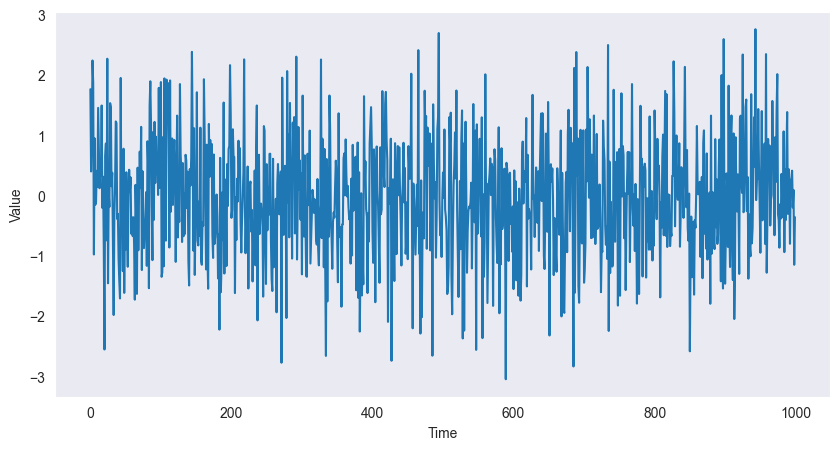

In [84]:
import matplotlib.pyplot as plt
import numpy as np

# White noise signal
w = np.random.normal(size=1000)

# plot
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(1, 1, 1)
ax.plot(w)
ax.grid()
plt.xlabel("Time")
plt.ylabel("Value")

plt.show()

- $W_1, W_2, \dots$ are i.i.d. with $E(W_i) = 0$, $\operatorname{Var}(W_i) = \sigma^2$
- No correlation: $\operatorname{Cov}(W_i, W_j) = 0$ for $i \ne j$
- Completely unpredictable
- ACF: $\rho(h) = 0$ for $h > 0$

**Random Walk:**

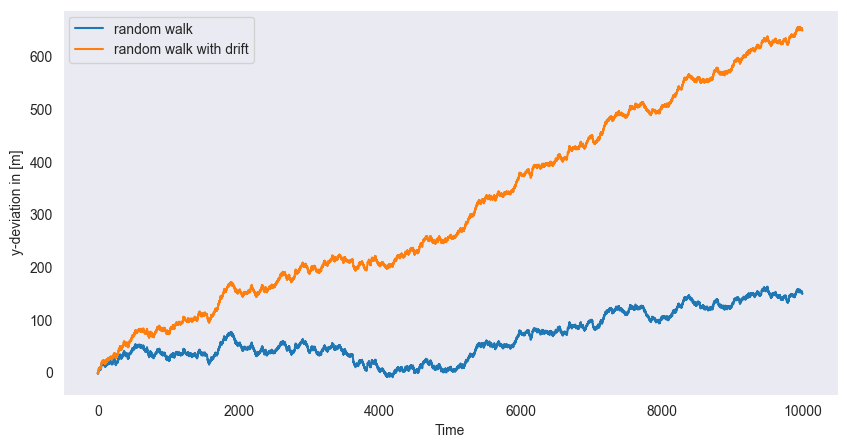

In [85]:
import matplotlib.pyplot as plt
import numpy as np

n_samp = 10000

# Random samples d and cumulative sum x
d = np.random.choice(a=[-1,1], size=n_samp, replace=True)
x = np.cumsum(d)

# Add drift delta
delta = 5e-2
y = np.linspace(0, n_samp * delta, n_samp)
y += x

# Plot
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(1, 1, 1)
ax.plot(x, label="random walk")
ax.plot(y, label="random walk with drift")
ax.grid()
plt.xlabel("Time")
plt.ylabel("y-deviation in [m]")
plt.legend()
plt.show()

- $X_n = X_{n-1} + W_n$, starting $X_0 = 0$
- Cumulative sum: $X_n = W_1 + W_2 + \dots + W_n$
- **With drift:** $X_n = X_{n-1} + \delta + W_n$ (adds trend $\delta$)
- Non-stationary (variance grows with time)
- $E(X_n) = n\delta$ (if drift), $\operatorname{Var}(X_n) = n \sigma^2$

**Moving Average (MA):**

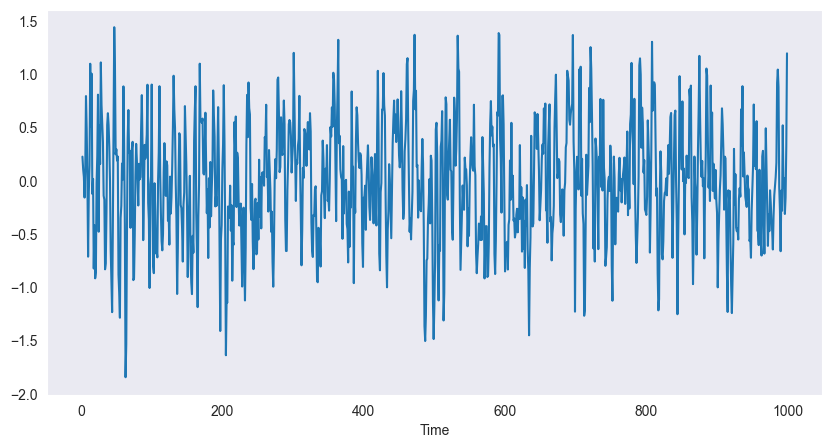

In [86]:
import numpy as np
import pandas as pd

w = np.random.normal(size=1000)
w = pd.DataFrame(w)

# Filter with window = 3
v = w.rolling(window=3).mean()

# plot
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(1, 1, 1)
ax.plot(v)
ax.grid()
plt.xlabel("Time")
plt.show()

- Example (3-point): $X_n = (W_{n-1} + W_n + W_{n+1}) / 3$
- Smooths white noise
- Reduces high-frequency fluctuations
- Stationary

**Autoregressive (AR):**

/var/folders/mg/f7gk10vj1_153rz1zkvd13_00000gn/T/ipykernel_13917/48771111.py:10: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  ar[i] = 1.5 * ar[i-1] - 0.9 * ar[i-2] + w.iloc[i]


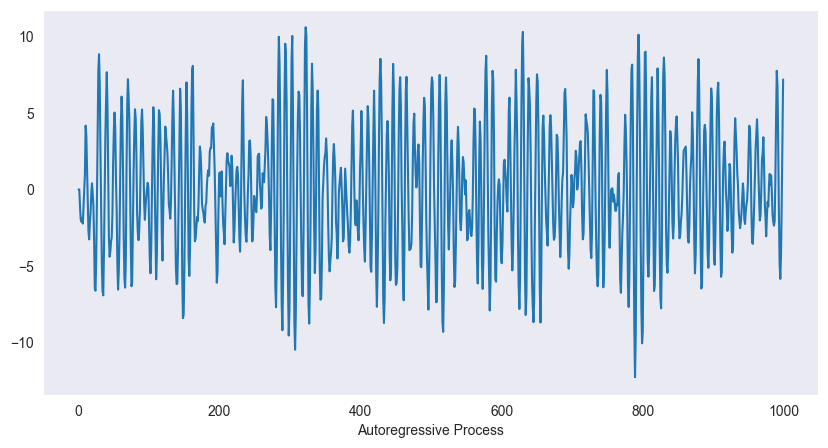

In [87]:
import numpy as np
import pandas as pd

w = np.random.normal(size=1000)
w = pd.DataFrame(w)

# Autoregressive filter:
ar = np.zeros(1000)
for i in range(2,1000):
    ar[i] = 1.5 * ar[i-1] - 0.9 * ar[i-2] + w.iloc[i]

# plot
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(1, 1, 1)
ax.plot(ar)
ax.grid()
plt.xlabel("Autoregressive Process")

plt.show()

- Example (AR(2)): $X_n = a_1 X_{n-1} + a_2 X_{n-2} + W_n$
- Current value depends on past values
- Can exhibit oscillations, trends (if non-stationary)
- Captures dependence structure

### Stationarity

/var/folders/mg/f7gk10vj1_153rz1zkvd13_00000gn/T/ipykernel_13917/1685250756.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  index = pd.DatetimeIndex(data=pd.to_datetime(df["Quarter"]), freq='infer')


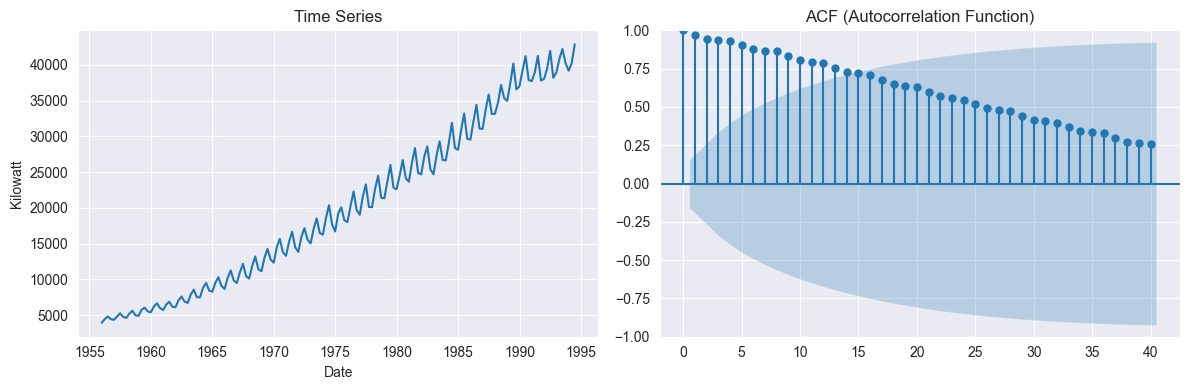

ADF Statistic: -0.27312130644566773 
p-value: 0.9292258325376282 
Critical Values:
  1%: -3.4776006742422374
  5%: -2.882265832283648
  10%: -2.5778219289774156
Fail to reject H₀: Series is non-stationary


In [88]:
import matplotlib.pyplot as plt
import pandas as pd
from statsmodels.graphics.tsaplots import plot_acf # autocorrelation function
from statsmodels.tsa.stattools import adfuller

df = pd.read_csv('predictive-modeling/AustralianElectricity.csv', sep =";")
index = pd.DatetimeIndex(data=pd.to_datetime(df["Quarter"]), freq='infer')
df.set_index(index, inplace=True)
df.drop("Quarter", axis=1, inplace=True)

# If ACF decays very slowly, the series is likely non-stationary (has trend or seasonality).
# Else-If ACF drops quickly to within confidence bands, the series is closer to stationary.

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(df.index, df["kilowatt"])
axes[0].set_title("Time Series")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Kilowatt")

plot_acf(df["kilowatt"], lags=40, ax=axes[1])
axes[1].set_title("ACF (Autocorrelation Function)")

plt.tight_layout()
plt.show()

##########################################################
# Augmented Dickey-Fuller test (formal stationarity test)
##########################################################

adfuller_results = adfuller(df["kilowatt"])
adf = adfuller_results[0]
pvalue = adfuller_results[1]
critical_values = adfuller_results[4]

print("ADF Statistic:", adf, "\np-value:", pvalue, "\nCritical Values:")
for key, value in critical_values.items():
    print(f"  {key}: {value}")

if pvalue < 0.05:
    print("Reject H₀: Series is stationary")
else:
    print("Fail to reject H₀: Series is non-stationary")

**Strict Stationarity:**

- Joint distribution unchanged by time shifts
- For any $h$, $(X_1, X_2, \dots, X_k)$ and $(X_{1+h}, X_{2+h}, \dots, X_{k+h})$ have same distribution
- Too strong for practice

**Weak Stationarity (Second-Order Stationarity):**
Two conditions:

1. **Constant mean:** $E(X_n) = \mu$ for all $n$
2. **Autocovariance depends only on lag:**
    - $\operatorname{Cov}(X_n, X_{n+h}) = \gamma(h)$ for all $n$
    - Doesn’t depend on absolute time $n$, only lag $h$

**Why Weak Stationarity Matters:**

- Allows statistical inference from single time series
- Can estimate autocovariance from one realization
- Most models assume weak stationarity

**Non-Stationary Indicators:**

- Trend (increasing/decreasing mean)
- Changing variance over time
- Seasonality (periodic pattern)
- ACF decays very slowly

**Stationarity for a Time Series** requires three conditions:

1. Constant mean: $\mathbb{E}[X_n] = \mu$ (independent of $n$)
2. Constant variance: $\text{Var}(X_n) = \gamma_0$ (independent of $n$)
3. Autocovariance depends only on lag: $\text{Cov}(X_n, X_{n-k}) = \gamma_k$ (independent of $n$)

For **ARMA processes**, a simpler criterion exists: the **characteristic equation** (or equivalently, checking the roots of the characteristic polynomial).

#### Proof Method 1: Characteristic Equation (Most Direct)

:::{attention} Two Different Conventions

**Convention 1: Lag Operator Form**

The characteristic polynomial is written as:

$$\Phi(z) = 1 - \phi_1 z^{-1} - \phi_2 z^{-2} - \cdots$$

**Stationarity condition:** All roots must satisfy **$|z| < 1$** (roots inside the unit circle)

**Convention 2: Direct Polynomial Form**

The characteristic polynomial is written as:

$$\Phi(x) = 1 - \phi_1 x + \phi_2 x^2 + \phi_3 x^3 + \cdots$$

**Stationarity condition:** All roots must satisfy **$|x| > 1$** (roots outside the unit circle)

---

These are **reciprocal polynomials**. If you compute roots of $\Phi(z)$, you get values inside the unit circle. If you compute roots of $\Phi(x)$, you get the **reciprocals** of those values—they lie outside the unit circle.
:::

**Convention 1: Rewrite the AR(2) process in lag operator notation:**

Rearrange to Standard Form (move all $X$ terms to the left side):

$$X_n - \frac{1}{2}X_{n-1} - \frac{1}{3}X_{n-2} = W_n$$

The characteristic equation is obtained by replacing $X_{n-k}$ with $z^{-k}$:

$$1 - \frac{1}{2}z^{-1} - \frac{1}{3}z^{-2} = 0$$

Multiply by $z^2$:

$$z^2 - \frac{1}{2}z - \frac{1}{3} = 0$$

This is the standard form for the quadratic formula: $az^2 + bz + c = 0$,

for which: $a = 1$, $b = -\frac{1}{2}$, $c = -\frac{1}{3}$.

In [89]:
# Coefficients in descending order of power:
np.abs(np.roots([1, -1/2, -1/3]))

array([0.87915287, 0.37915287])

**Both roots satisfy $|z| < 1$** (they lie inside the unit circle). Since both roots of the characteristic polynomial lie strictly inside the unit circle, the AR(2) process is **stationary**.

**Convention 2: Rewrite the AR(2) process into its Characteristic Polynomial:**

Rearrange to Standard Form (move all $X$ terms to the left side):

$$X_n - 0.5X_{n-1} + 0.5X_{n-2} + 0.1X_{n-3} = W_n$$

Introduce the Lag Operator (Backshift Operator):

Define the **lag operator** $L$ such that: $LX_n = X_{n-1}$, $L^2X_n = X_{n-2}$, $L^3X_n = X_{n-3}$ and rewrite the equation using $L$:

$$X_n - 0.5LX_n + 0.5L^2X_n + 0.1L^3X_n = W_n$$

Factor out $X_n$ on the left:

$$(1 - 0.5L + 0.5L^2 + 0.1L^3)X_n = W_n$$

This is the **lag polynomial form**: $\Phi(L)X_n = W_n$

where $\Phi(L) = 1 - 0.5L + 0.5L^2 + 0.1L^3$

Direct Polynomial Substitution: Replace $L$ with $x$, set equal to zero and rearrange to standard form (coefficients in descending order of power):

$$0.1x^3 + 0.5x^2 - 0.5x + 1= 0$$

**Stationarity condition:** All roots satisfy $|x| > 1$

In [90]:
# Coefficients in descending order of power:
np.abs(np.roots([0.1, 1/2, -1/2, 1]))

array([6.09052833, 1.28136399, 1.28136399])



**Solve Manually for roots using the quadratic formula:**

$$
z = \frac{-b \pm \sqrt{b^2 - 4ac}}{2a} = \frac{\frac{1}{2} \pm \sqrt{\frac{1}{4} + \frac{4}{3}}}{2} = \frac{\frac{1}{2} \pm \sqrt{\frac{3 + 16}{12}}}{2} = \frac{\frac{1}{2} \pm \sqrt{\frac{19}{12}}}{2} = \frac{\frac{1}{2} \pm \frac{\sqrt{19}}{2\sqrt{3}}}{2}$$

Numerically: $\sqrt{19} \approx 4.359$, so $\sqrt{\frac{19}{12}} \approx 1.258$

$$z_1 \approx \frac{0.5 + 1.258}{2} \approx 0.879$$

$$z_2 \approx \frac{0.5 - 1.258}{2} \approx -0.379$$

#### Proof Method 2: Verification via Mean (Supporting Proof)

Assuming stationarity, let $\mu = \mathbb{E}[X_n]$. Taking expectations of both sides:

$$\mathbb{E}[X_n] = \frac{1}{2}\mathbb{E}[X_{n-1}] + \frac{1}{3}\mathbb{E}[X_{n-2}] + \mathbb{E}[W_n]$$

$$\mu = \frac{1}{2}\mu + \frac{1}{3}\mu + 0$$

$$\mu\left(1 - \frac{1}{2} - \frac{1}{3}\right) = 0$$

$$\mu \cdot \frac{1}{6} = 0 \implies \mu = 0$$

The mean is well-defined and constant at $\mu = 0$, consistent with stationarity.

### Autocovariance & Autocorrelation Functions

**Theoretical Autocovariance Function (ACOVF):**

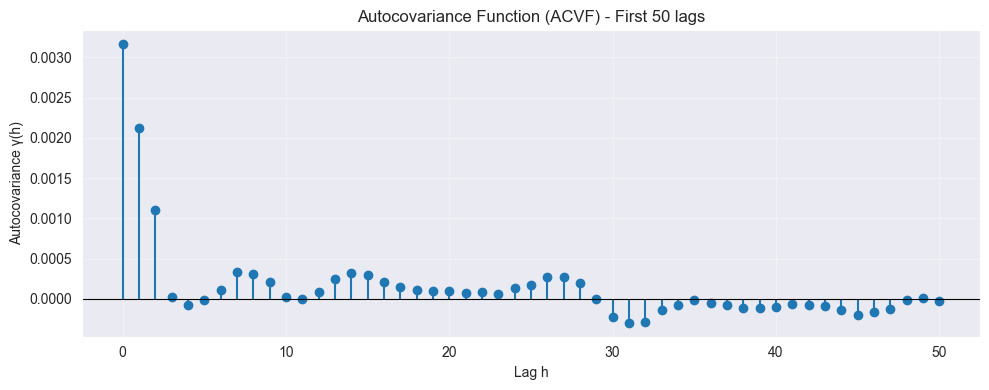

In [91]:
import numpy as np
import pandas as pd
from statsmodels.tsa.stattools import acovf # autocovariance function

np.random.seed(0)

w = np.random.normal(size=1000, loc=2, scale=0.1)
w = pd.DataFrame(w)
w = w.rolling(window=3).mean()

gamma = acovf(w, adjusted=False, missing='drop', fft=False)
n_lags = 50  # Plot first n lags, use len(gamma) - 1 for all lags

plt.figure(figsize=(10, 4))
plt.stem(range(n_lags+1), gamma[:n_lags+1], basefmt=" ")
plt.axhline(0, color='black', linewidth=0.8)
plt.xlabel("Lag h")
plt.ylabel("Autocovariance γ(h)")
plt.title(f"Autocovariance Function (ACVF) - First {n_lags} lags")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

- $\gamma(h) = \operatorname{Cov}(X_n, X_{n+h}) = E[(X_n - \mu)(X_{n+h} - \mu)]$
- $\gamma(0) = \operatorname{Var}(X_n)$
- $\gamma(h) = \gamma(-h)$ (symmetric)

**Sample Autocovariance:**

- $\hat\gamma(h) = \dfrac{1}{n} \sum_{i=1}^{n-h} (x_{i+h} - \bar x)(x_i - \bar x)$

**Theoretical Autocorrelation Function (ACF):**

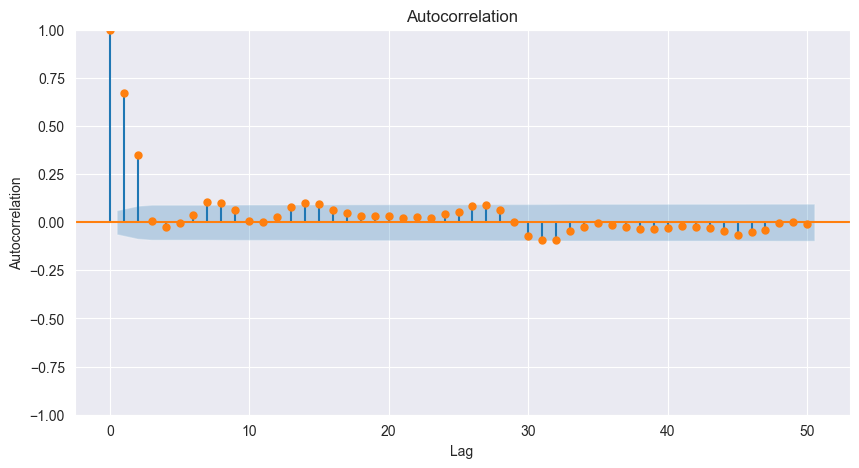

Autocorrelation = [1.         0.67030704 0.34969521]


In [92]:
import numpy as np
import pandas as pd

from statsmodels.tsa.stattools import acf # autocorrelation function
from statsmodels.graphics.tsaplots import plot_acf # plot autocorrelation function

np.random.seed(0)

w = np.random.normal(size=1000, loc=2, scale=0.1)
w = pd.DataFrame(w)
w = w.rolling(window=3).mean()

fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(1, 1, 1)
plot_acf(w, missing='drop', lags=50, ax=ax, c='C1')
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.show()

print(f"Autocorrelation = {acf(w, missing='drop', nlags=3 - 1, fft=True)}")

- $\rho(h) = \gamma(h) / \gamma(0) = \operatorname{Cor}(X_n, X_{n+h})$
- $\rho(0) = 1$
- $-1 \le \rho(h) \le 1$
- Measures linear dependence at lag $h$

**Sample Autocorrelation:**

- $\hat\rho(h) = \hat\gamma(h) / \hat\gamma(0)$

**White Noise ACF:**

- For white noise with large $n$: $\hat\rho(h) \sim N(0, 1/n)$ for $h > 0$
- 95% confidence bands: $\pm 1.96/\sqrt{n}$
- If $\lvert\hat\rho(h)\rvert < 1.96/\sqrt{n}$ for all $h > 0$ → consistent with white noise

**Interpretation:**

- $\rho(h) \approx 0$: no linear relationship at lag $h$
- $\rho(h) > 0$: positive correlation (peaks followed by peaks)
- $\rho(h) < 0$: negative correlation (peaks followed by troughs)

### Transformations

**Purpose:** Achieve stationarity, stabilize variance, reduce skewness

**Box-Cox Transformation:**

Optimal λ: 0.4818


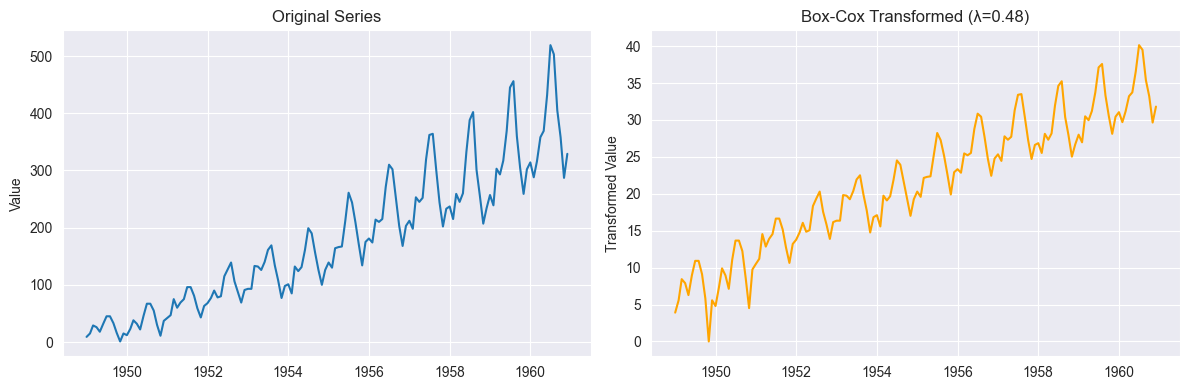

In [93]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import boxcox

df = pd.read_csv('predictive-modeling/AirPassengers.csv', parse_dates=True)
index = pd.DatetimeIndex(data=pd.to_datetime(df["TravelDate"]), freq='infer')
df.set_index(index, inplace=True)
df.drop("TravelDate", axis=1, inplace=True)

# Apply Box-Cox transformation (requires positive data)
y_positive = df["Passengers"] - df["Passengers"].min() + 1  # Shift to make positive
y_boxcox, lambda_opt = boxcox(y_positive)

print(f"Optimal λ: {lambda_opt:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(df.index, y_positive, label="Original")
axes[0].set_title("Original Series")
axes[0].set_ylabel("Value")

axes[1].plot(df.index, y_boxcox, label="Box-Cox Transformed", color="orange")
axes[1].set_title(f"Box-Cox Transformed (λ={lambda_opt:.2f})")
axes[1].set_ylabel("Transformed Value")

plt.tight_layout()
plt.show()

```text
g(x) = (x^λ - 1)/λ   if λ ≠ 0
g(x) = log(x)        if λ = 0
```

- $\lambda = 1$: no transformation
- $\lambda = 0.5$: square root
- $\lambda = 0$: logarithm
- $\lambda = -1$: reciprocal
- Choose $\lambda$ to stabilize variance and reduce skewness

**Differencing:**

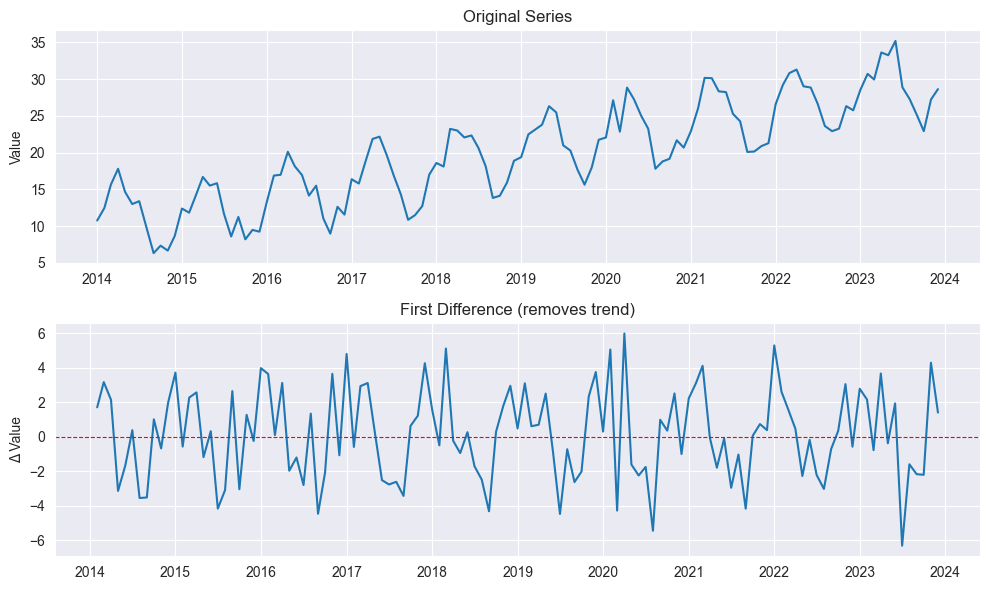

In [94]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Generate synthetic monthly time series with trend and seasonality
np.random.seed(42)

n = 120  # 10 years of monthly data
time = pd.date_range(start='2014-01', periods=n, freq='MS')

# Trend + Seasonality + Noise
trend = np.linspace(10, 30, n)
seasonal = 5 * np.sin(2 * np.pi * np.arange(n) / 12)  # 12-month cycle
noise = np.random.normal(scale=1.5, size=n)
y = trend + seasonal + noise

df = pd.DataFrame({"date": time, "value": y})
df.set_index("date", inplace=True)

df["diff1"] = df["value"].diff()

fig, axes = plt.subplots(2, 1, figsize=(10, 6))

axes[0].plot(df.index, df["value"])
axes[0].set_title("Original Series")
axes[0].set_ylabel("Value")

axes[1].plot(df.index, df["diff1"])
axes[1].set_title("First Difference (removes trend)")
axes[1].set_ylabel("Δ Value")
axes[1].axhline(0, color='red', linestyle='--', linewidth=0.8)

plt.tight_layout()
plt.show()

- First difference: $\nabla x_n = x_n - x_{n-1}$
- Removes linear trend
- Backshift operator: $B x_n = x_{n-1}$
- Differencing operator: $\nabla = (1 - B)$
- Second difference: $\nabla^2 x_n = \nabla(\nabla x_n) = x_n - 2 x_{n-1} + x_{n-2}$

**Seasonal Differencing:**

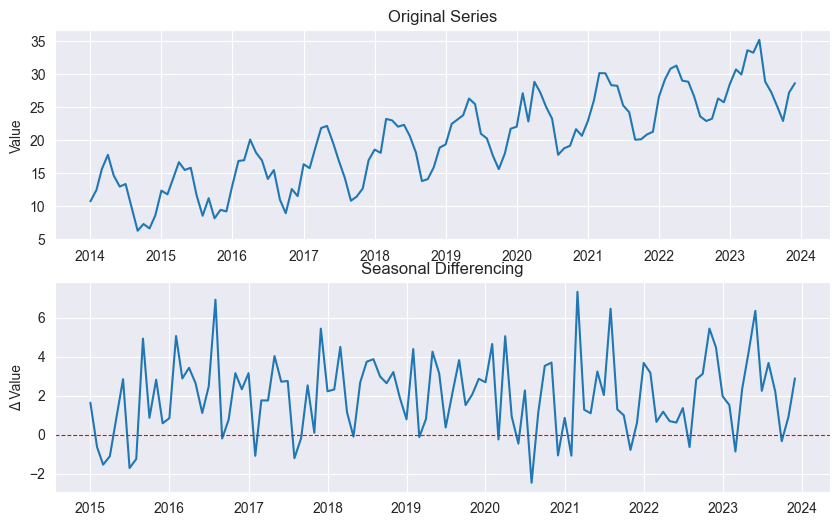

In [95]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Generate synthetic monthly time series with trend and seasonality
np.random.seed(42)

n = 120  # 10 years of monthly data
time = pd.date_range(start='2014-01', periods=n, freq='MS')

# Trend + Seasonality + Noise
trend = np.linspace(10, 30, n)
seasonal = 5 * np.sin(2 * np.pi * np.arange(n) / 12)  # 12-month cycle
noise = np.random.normal(scale=1.5, size=n)
y = trend + seasonal + noise

df = pd.DataFrame({"date": time, "value": y})
df.set_index("date", inplace=True)

# Seasonal difference (12-month period)
df["seasonal_diff"] = df["value"].diff(12)

fig, axes = plt.subplots(2, 1, figsize=(10, 6))

axes[0].plot(df.index, df["value"])
axes[0].set_title("Original Series")
axes[0].set_ylabel("Value")

axes[1].plot(df.index, df["seasonal_diff"], label="Seasonal Difference (lag=12)")
axes[1].set_title("Seasonal Differencing")
axes[1].set_ylabel("Δ Value")
axes[1].axhline(0, color='red', linestyle='--', linewidth=0.8)

plt.show()

- $\nabla_s x_n = x_n - x_{n-s}$ ($s$ = seasonal period, e.g., $s=12$ for monthly)
- Removes seasonal pattern

**Log-Returns (Finance):**

- $r_n = \log(x_n) - \log(x_{n-1}) = \log(x_n/x_{n-1})$
- Approximates relative change: $(x_n - x_{n-1})/x_{n-1}$
- Often stationary even when prices non-stationary

### Time Series Decomposition

**Additive Model:**

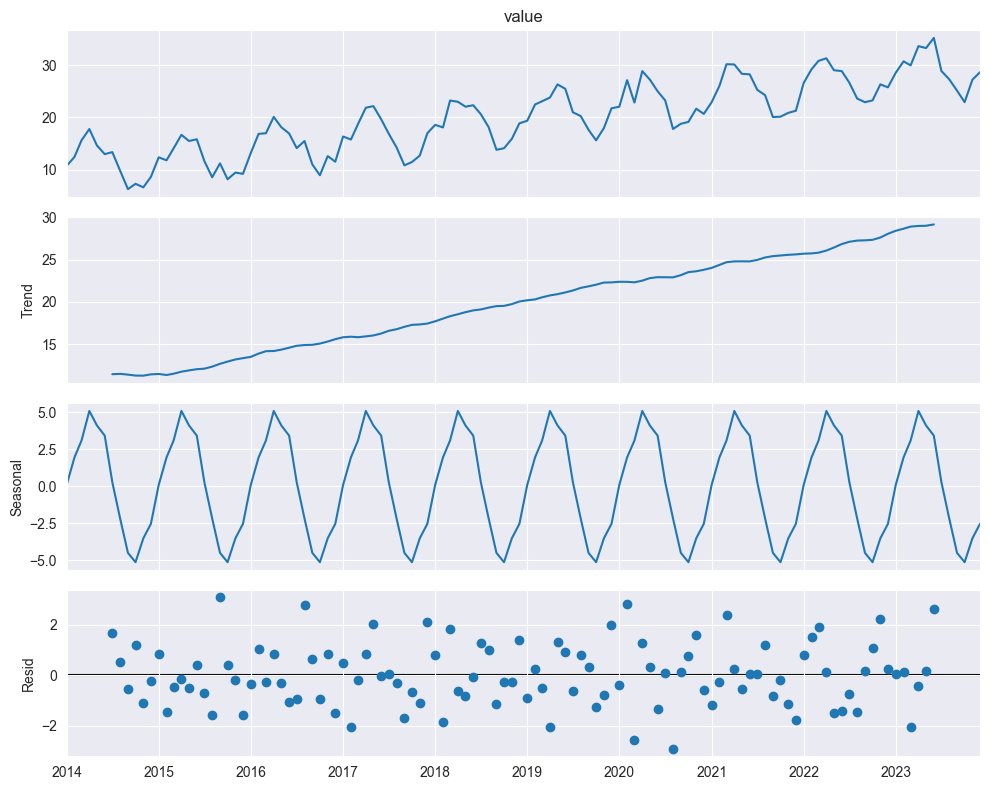

In [96]:
import numpy as np
import pandas as pd
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

# Generate synthetic monthly time series with trend and seasonality
np.random.seed(42)

n = 120  # 10 years of monthly data
time = pd.date_range(start='2014-01', periods=n, freq='MS')

# Trend + Seasonality + Noise
trend = np.linspace(10, 30, n)
seasonal = 5 * np.sin(2 * np.pi * np.arange(n) / 12)  # 12-month cycle
noise = np.random.normal(scale=1.5, size=n)
y = trend + seasonal + noise

df = pd.DataFrame({"date": time, "value": y})
df.set_index("date", inplace=True)

# Additive decomposition
decomposition = seasonal_decompose(df["value"], model='additive', period=12)

fig = decomposition.plot()
fig.set_size_inches(10, 8)
plt.tight_layout()
plt.show()

$x_n = m_n + s_n + z_n$

- $m_n$: trend component
- $s_n$: seasonal component
- $z_n$: remainder (irregular, noise)

**When to use additive:**

- Seasonal variation roughly constant over time

**Multiplicative Model:**

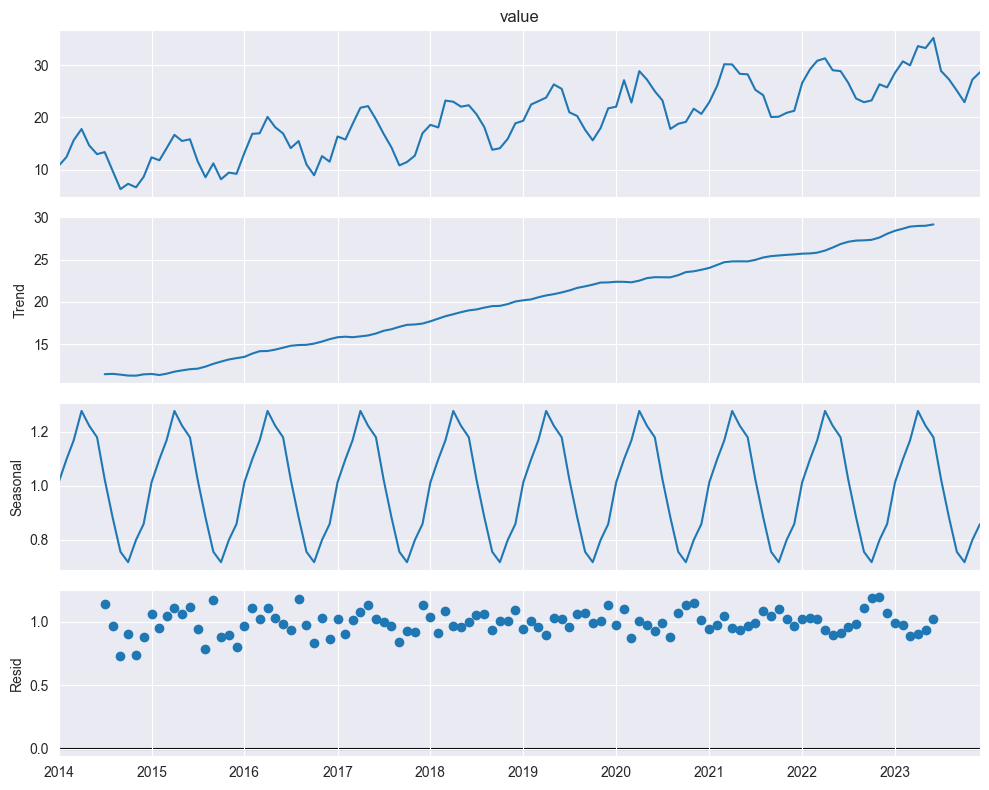

In [97]:
import numpy as np
import pandas as pd
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

# Generate synthetic monthly time series with trend and seasonality
np.random.seed(42)

n = 120  # 10 years of monthly data
time = pd.date_range(start='2014-01', periods=n, freq='MS')

# Trend + Seasonality + Noise
trend = np.linspace(10, 30, n)
seasonal = 5 * np.sin(2 * np.pi * np.arange(n) / 12)  # 12-month cycle
noise = np.random.normal(scale=1.5, size=n)
y = trend + seasonal + noise

df = pd.DataFrame({"date": time, "value": y})
df.set_index("date", inplace=True)

# Additive decomposition
decomposition = seasonal_decompose(df["value"], model='multiplicative', period=12)

fig = decomposition.plot()
fig.set_size_inches(10, 8)
plt.tight_layout()
plt.show()



$x_n = m_n \times s_n \times z_n$

**When to use multiplicative:**

- Seasonal variation grows/shrinks with trend
- Can take logs: $\log(x_n) = \log(m_n) + \log(s_n) + \log(z_n)$ (additive!)

**Classical Decomposition (Moving Average Method):**

1. **Estimate Trend $m_n$:**
    - Apply moving average filter of length $p$ (= seasonal period)
    - For monthly data ($p=12$): average over 12 months
    - Smooths out seasonality
2. **Estimate Seasonal Effect $s_n$:**
    - Compute detrended series: $d_n = x_n - m_n$
    - For each position in cycle (e.g., each month):
        - Average all detrended values at that position
    - Result: seasonal pattern that repeats
3. **Estimate Remainder $z_n$:**
    - $r_n = x_n - m_n - s_n$
    - Should be random (no structure)

**Moving Average Filter:**

- For odd $p = 2\ell+1$: $\hat m_n = \dfrac{1}{p} \sum_{i=-\ell}^{\ell} x_{n+i}$
- For even $p = 2\ell$:
$\hat m_n = \dfrac{1}{p} \left[0.5 x_{n-\ell} + x_{n-\ell+1} + \dots + x_{n+\ell-1} + 0.5 x_{n+\ell}\right]$

**STL (Seasonal-Trend Decomposition using Loess):**

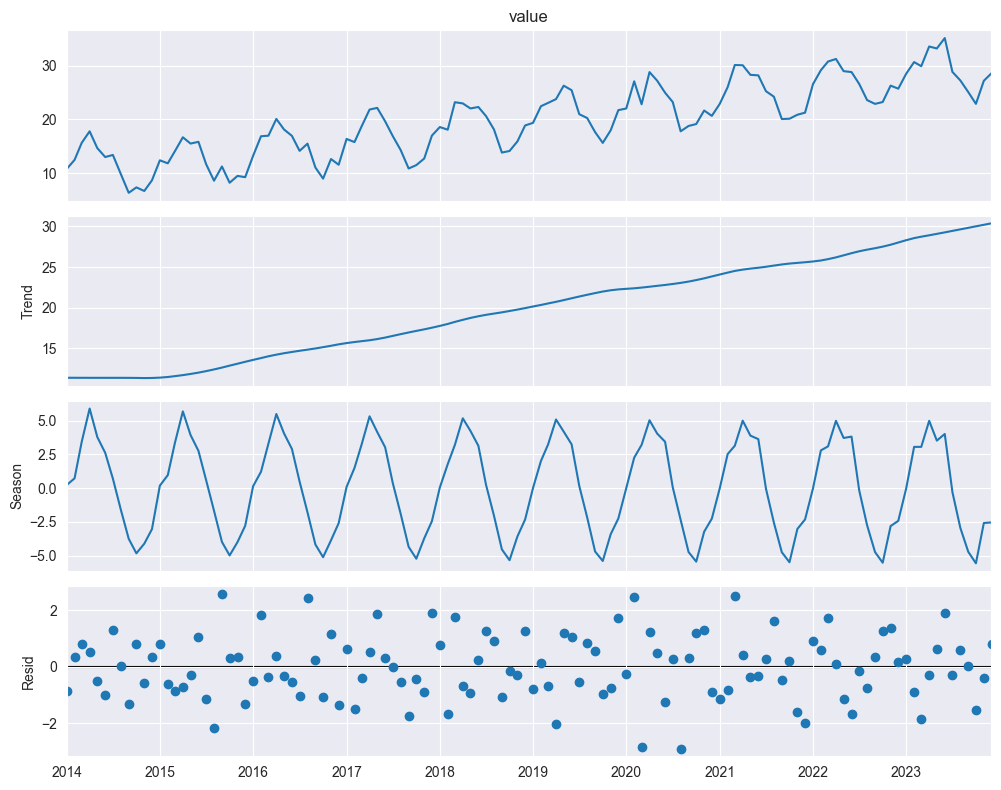

Trend (first 5): [11.3892355  11.386162   11.38341052 11.38170419 11.38106562]
Seasonal (first 5): [0.22258345 0.72413073 3.43459021 5.89856111 3.7861149 ]
Residual (first 5): [-0.86674771  0.35037805  0.81979354  0.50848116 -0.51601466]


In [98]:
import numpy as np
import pandas as pd
from statsmodels.tsa.seasonal import STL
import matplotlib.pyplot as plt

# Generate synthetic monthly time series with trend and seasonality
np.random.seed(42)

n = 120  # 10 years of monthly data
time = pd.date_range(start='2014-01', periods=n, freq='MS')

# Trend + Seasonality + Noise
trend = np.linspace(10, 30, n)
seasonal = 5 * np.sin(2 * np.pi * np.arange(n) / 12)  # 12-month cycle
noise = np.random.normal(scale=1.5, size=n)
y = trend + seasonal + noise

# STL decomposition
stl = STL(df["value"], period=12, seasonal=13)  # seasonal window must be odd
result = stl.fit()

fig = result.plot()
fig.set_size_inches(10, 8)
plt.tight_layout()
plt.show()

trend_stl = result.trend
seasonal_stl = result.seasonal
residual_stl = result.resid

print("Trend (first 5):", trend_stl[:5].values)
print("Seasonal (first 5):", seasonal_stl[:5].values)
print("Residual (first 5):", residual_stl[:5].values)



- More flexible than classical decomposition
- Uses loess (local regression) instead of moving averages
- Seasonal component can change over time
- Robust to outliers
- Iterative procedure

**Advantages of STL:**

- Handles any type of seasonality
- Seasonal component can vary slowly
- Robustness to unusual observations
- More accurate trend and seasonal estimates

## Time Series: AR, MA, ARMA & ARIMA Models

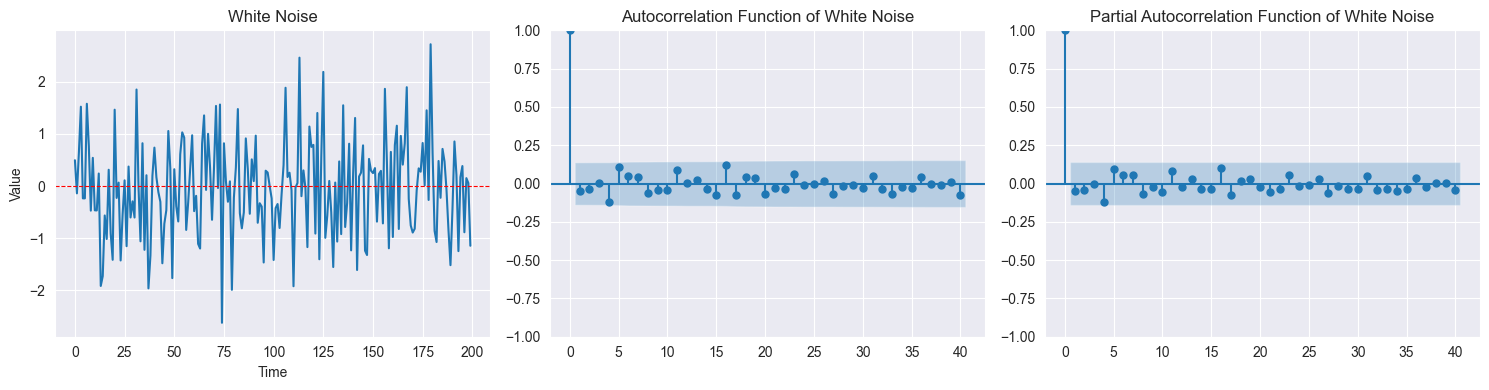

In [99]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

np.random.seed(42)

# Generate white noise
n = 200
z = np.random.normal(loc=0, scale=1, size=n)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Time series plot
axes[0].plot(z)
axes[0].set_title("White Noise")
axes[0].set_xlabel("Time")
axes[0].set_ylabel("Value")
axes[0].axhline(0, color='red', linestyle='--', linewidth=0.8)

# Autocorrelation Function
plot_acf(z, lags=40, ax=axes[1])
axes[1].set_title("Autocorrelation Function of White Noise")

# Partial Autocorrelation Function
plot_pacf(z, lags=40, ax=axes[2])
axes[2].set_title("Partial Autocorrelation Function of White Noise")

plt.tight_layout()
plt.show()


### Autoregressive Model AR($p$)

**Definition:**
$X_n = a_1 X_{n-1} + a_2 X_{n-2} + \dots + a_p X_{n-p} + W_n$

- $p$: order (number of lagged terms)
- $a_1, \dots, a_p$: AR coefficients
- $W_n$: white noise with variance $\sigma^2$

**AR Operator \& Characteristic Polynomial:**

- $\varphi(B) = 1 - a_1 B - a_2 B^2 - \dots - a_p B^p$
- $\varphi(B) X_n = W_n$
- Characteristic polynomial: $\varphi(z) = 1 - a_1 z - a_2 z^2 - \dots - a_p z^p$

**Stationarity Condition:**

- All roots of $\varphi(z) = 0$ must satisfy $|z| > 1$
- Equivalently: all zeros outside unit circle in complex plane

**AR(1) Example:** $X_n = a X_{n-1} + W_n$

Is stationary? True
Is invertible? True


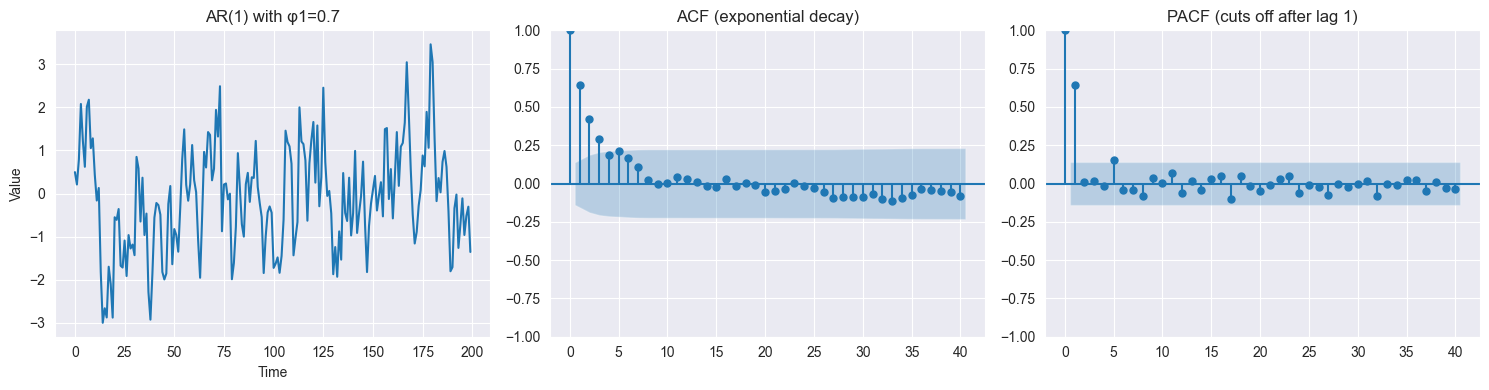

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  200
Model:                 ARIMA(1, 0, 0)   Log Likelihood                -268.801
Date:                Wed, 28 Jan 2026   AIC                            543.602
Time:                        19:12:39   BIC                            553.497
Sample:                             0   HQIC                           547.606
                                - 200                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1257      0.187     -0.670      0.503      -0.493       0.242
ar.L1          0.6478      0.056     11.570      0.000       0.538       0.757
sigma2         0.8585      0.086      9.974      0.0

In [100]:
from statsmodels.tsa.arima_process import ArmaProcess

########################
# Simulate AR(1) process
#########################
# AR(1): x_n = 0.7 * x_{n-1} + z_n
phi = [1, -0.7]  # [1, -φ₁] format; Stationarity requires |φ₁| < 1
theta = [1]      # MA coefficients (none for pure AR)

arma_process = ArmaProcess(phi, theta)

# Check stationarity
print("Is stationary?", arma_process.isstationary)
print("Is invertible?", arma_process.isinvertible)

# Simulate AR(1)
np.random.seed(42)

data = arma_process.generate_sample(nsample=200)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(data)
axes[0].set_title("AR(1) with φ1=0.7")
axes[0].set_xlabel("Time")
axes[0].set_ylabel("Value")

plot_acf(data, lags=40, ax=axes[1])
axes[1].set_title("ACF (exponential decay)")

plot_pacf(data, lags=40, ax=axes[2])
axes[2].set_title("PACF (cuts off after lag 1)")

plt.tight_layout()
plt.show()

###################################
# Estimate AR(1) using statsmodels
###################################

from statsmodels.tsa.arima.model import ARIMA

# Fit AR(1) model: ARIMA(1,0,0)
model = ARIMA(data, order=(1, 0, 0)).fit()

print(model.summary())

- Stationary if $|a| < 1$
- Variance: $\operatorname{Var}(X_n) = \sigma^2/(1 - a^2)$
- ACF: $\rho(h) = a^h$ (exponential decay)
- PACF: $\phi_{11} = a$, $\phi_{hh} = 0$ for $h > 1$

**AR(2) Example:** $X_n = a_1 X_{n-1} + a_2 X_{n-2} + W_n$

AR(2) is stationary? True


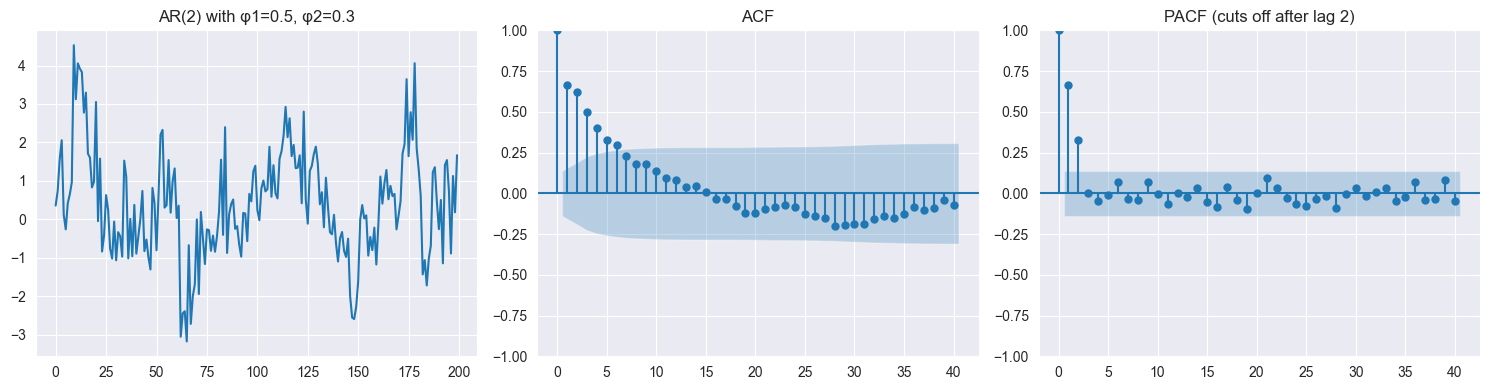

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  200
Model:                 ARIMA(2, 0, 0)   Log Likelihood                -280.673
Date:                Wed, 28 Jan 2026   AIC                            569.346
Time:                        19:12:40   BIC                            582.539
Sample:                             0   HQIC                           574.685
                                - 200                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.4153      0.305      1.362      0.173      -0.182       1.013
ar.L1          0.4462      0.066      6.715      0.000       0.316       0.576
ar.L2          0.3237      0.067      4.799      0.0

In [101]:
########################
# Simulate AR(2) process
########################
phi = [1, -0.5, -0.3]  # [1, -φ₁, -φ₂]
theta = [1]

arma_process = ArmaProcess(phi, theta)
print("AR(2) is stationary?", arma_process.isstationary)

data = arma_process.generate_sample(nsample=200, scale=1.0)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(data)
axes[0].set_title("AR(2) with φ1=0.5, φ2=0.3")

plot_acf(data, lags=40, ax=axes[1])
axes[1].set_title("ACF")

plot_pacf(data, lags=40, ax=axes[2])
axes[2].set_title("PACF (cuts off after lag 2)")

plt.tight_layout()
plt.show()

###################################
# Estimate AR(1) using statsmodels
###################################

from statsmodels.tsa.arima.model import ARIMA

# Fit AR(2) model: ARIMA(2,0,0)
model = ARIMA(data, order=(2, 0, 0)).fit()

print(model.summary())

- Characteristic polynomial: $\varphi(z) = 1 - a_1 z - a_2 z^2$
- Find roots, check $|z| > 1$

**ACF Pattern for AR($p$):**

- Exponential decay (possibly with oscillations)
- Tails off gradually
- No clear cutoff

**PACF Pattern for AR($p$):**

- Cuts off after lag $p$
- $\phi_{pp} \ne 0$, $\phi_{hh} \approx 0$ for $h > p$
- **Use PACF to identify order $p$!**

**Partial Autocorrelation:**

- $\phi_{hh} = \operatorname{Cor}(X_n, X_{n+h} \mid X_{n+1}, \dots, X_{n+h-1})$
- Correlation after removing effect of intermediate lags
- For AR($p$): $\phi_{pp}$ equals $a_p$ coefficient

### Moving Average Model MA($q$)

**Definition:**
$X_n = W_n + b_1 W_{n-1} + b_2 W_{n-2} + \dots + b_q W_{n-q}$

- $q$: order (number of lagged noise terms)
- $b_1, \dots, b_q$: MA coefficients
- $W_n$: white noise

**MA Operator:**

- $\theta(B) = 1 + b_1 B + b_2 B^2 + \dots + b_q B^q$
- $X_n = \theta(B) W_n$

**Key Property:** MA processes are **always stationary**

- Mean: $E(X_n) = 0$
- Variance: $\operatorname{Var}(X_n) = (1 + b_1^2 + \dots + b_q^2)\sigma^2$

**Invertibility Condition:**

- All roots of $\theta(z) = 0$ must satisfy $|z| > 1$
- Ensures unique MA representation
- Allows writing MA as infinite AR

**MA(1) Example:** $X_n = W_n + b W_{n-1}$

Is invertible? True


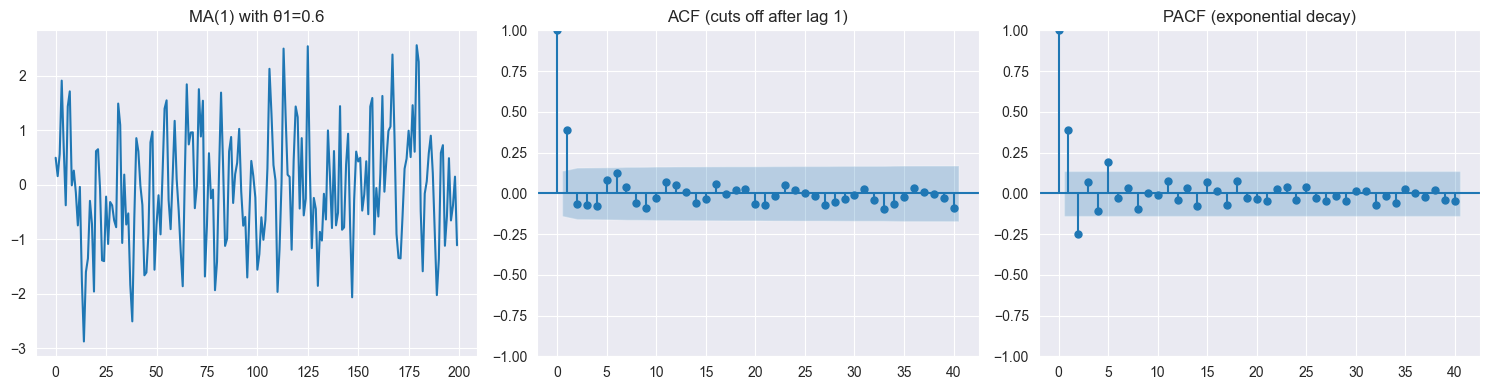

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  200
Model:                 ARIMA(0, 0, 1)   Log Likelihood                -269.176
Date:                Wed, 28 Jan 2026   AIC                            544.352
Time:                        19:12:40   BIC                            554.247
Sample:                             0   HQIC                           548.357
                                - 200                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0641      0.106     -0.604      0.546      -0.272       0.144
ma.L1          0.6081      0.057     10.647      0.000       0.496       0.720
sigma2         0.8621      0.087      9.884      0.0

In [102]:
########################
# Simulate MA(1) process
########################
# MA(1): x_n = z_n + 0.6*z_{n-1}
phi = [1]       # No AR part
theta = [1, 0.6]  # [1, θ₁] # Invertibility requires |θ₁| < 1

arma_process = ArmaProcess(phi, theta)
print("Is invertible?", arma_process.isinvertible)

np.random.seed(42)
data = arma_process.generate_sample(nsample=200)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(data)
axes[0].set_title("MA(1) with θ1=0.6")

plot_acf(data, lags=40, ax=axes[1])
axes[1].set_title("ACF (cuts off after lag 1)")

plot_pacf(data, lags=40, ax=axes[2])
axes[2].set_title("PACF (exponential decay)")

plt.tight_layout()
plt.show()

################
# Estimate MA(1)
################

model = ARIMA(data, order=(0, 0, 1)).fit()
print(model.summary())

- Variance: $\operatorname{Var}(X_n) = (1 + b^2)\sigma^2$
- $\operatorname{Cov}(X_n, X_{n+1}) = b \sigma^2$
- ACF: $\rho(1) = b/(1 + b^2)$, $\rho(h) = 0$ for $h \ge 2$
- Invertible if $|b| < 1$

**ACF Pattern for MA($q$):**

- Cuts off after lag $q$
- $\rho(h) \ne 0$ for $h \le q$
- $\rho(h) = 0$ for $h > q$
- **Use ACF to identify order $q$!**

**PACF Pattern for MA($q$):**

- Exponential decay (possibly with oscillations)
- Tails off gradually
- No clear cutoff

### ARMA($p,q$) Model

**Definition:**
$\varphi(B) X_n = \theta(B) W_n$

Or: $(1 - a_1 B - \dots - a_p B^p) X_n = (1 + b_1 B + \dots + b_q B^q) W_n$

Expanded:
$X_n = a_1 X_{n-1} + \dots + a_p X_{n-p} + W_n + b_1 W_{n-1} + \dots + b_q W_{n-q}$

**Properties:**

- Combines AR and MA components
- More flexible than pure AR or MA
- Fewer parameters than pure AR or MA

**Stationarity:** All roots of $\varphi(z) = 0$ satisfy $|z| > 1$
**Invertibility:** All roots of $\theta(z) = 0$ satisfy $|z| > 1$

**ACF \& PACF Patterns:**

- **Both tail off** (no clear cutoff in either)
- Hard to identify orders $p$ and $q$ from ACF/PACF alone
- Use information criteria (AIC, BIC)

**Model Selection Strategy:**

1. Plot ACF and PACF
2. If ACF cuts off → MA($q$)
3. If PACF cuts off → AR($p$)
4. If both tail off → ARMA($p,q$)
5. For ARMA, try grid of $(p,q)$ values
6. Choose model with lowest AIC or BIC

**Estimation:**

- Maximum likelihood method
- Iterative numerical optimization
- Software: `statsmodels` (Python), `forecast` (R)

Stationary? True
Invertible? True


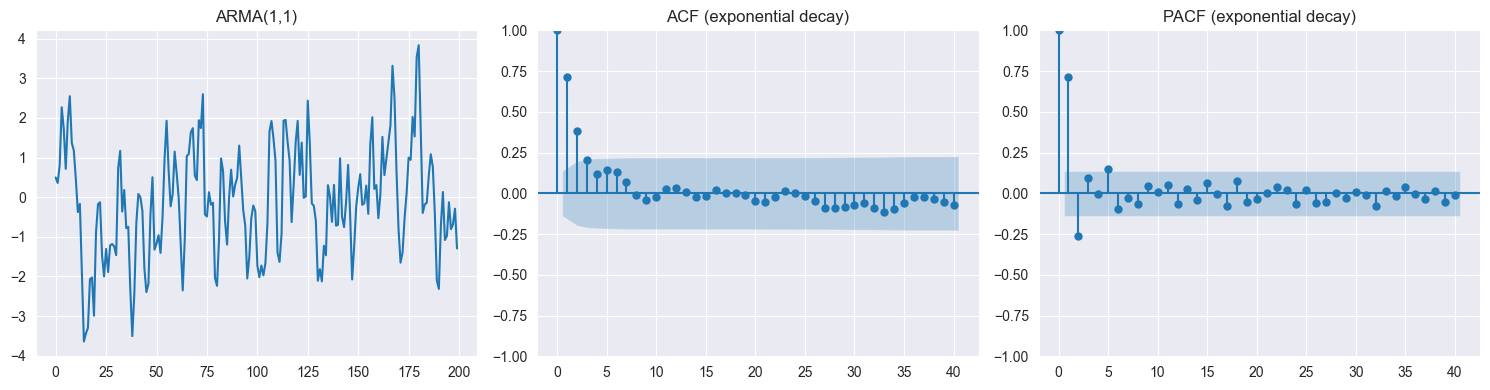

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  200
Model:                 ARIMA(1, 0, 1)   Log Likelihood                -268.841
Date:                Wed, 28 Jan 2026   AIC                            545.682
Time:                        19:12:41   BIC                            558.875
Sample:                             0   HQIC                           551.021
                                - 200                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1340      0.197     -0.679      0.497      -0.521       0.253
ar.L1          0.5204      0.086      6.074      0.000       0.352       0.688
ma.L1          0.4313      0.088      4.885      0.0

In [103]:
#####################
# Simulate ARMA(1,1)
#####################

# ARMA(1,1): x_n = 0.6*x_{n-1} + z_n + 0.4*z_{n-1}
phi = [1, -0.6]  # AR part
theta = [1, 0.4]  # MA part

arma_process = ArmaProcess(phi, theta)
print("Stationary?", arma_process.isstationary)
print("Invertible?", arma_process.isinvertible)

np.random.seed(42)
data = arma_process.generate_sample(nsample=200)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(data)
axes[0].set_title("ARMA(1,1)")

plot_acf(data, lags=40, ax=axes[1])
axes[1].set_title("ACF (exponential decay)")

plot_pacf(data, lags=40, ax=axes[2])
axes[2].set_title("PACF (exponential decay)")

plt.tight_layout()
plt.show()


#####################
# Estimate ARMA(1,1)
#####################
model = ARIMA(data, order=(1, 0, 1)).fit()
print(model.summary())

### ARIMA($p,d,q$) Model

**Purpose:** Model non-stationary series

**Definition:**
$\varphi(B) \nabla^d X_n = \theta(B) W_n$

- $d$: degree of differencing
- $\nabla = (1 - B)$: differencing operator
- $\nabla^d = (1 - B)^d$: difference $d$ times

**Idea:**

- Original series $X_n$ non-stationary
- Difference $d$ times to get stationary series $Y_n = \nabla^d X_n$
- Fit ARMA($p,q$) to $Y_n$
- Result: ARIMA($p,d,q$) for $X_n$

**Common Cases:**

- **ARIMA($p,0,q$)** = ARMA($p,q$) (already stationary)
- **ARIMA($p,1,q$):** First-difference, then ARMA
- **ARIMA($0,1,0$):** Random walk ($\nabla X_n = W_n$)
- **ARIMA($0,1,0$) with drift:** Random walk with drift
- **ARIMA($0,2,2$):** Local linear trend model

**Model Building Process (Box-Jenkins):**

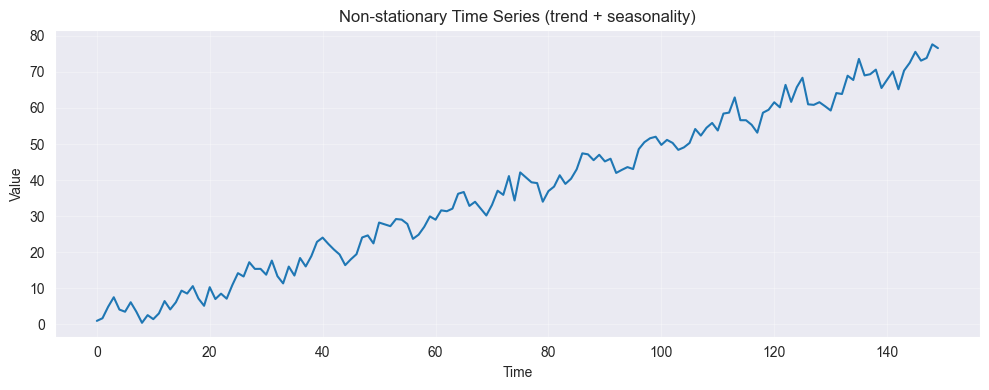

In [104]:
###########################################
# Generate non-stationary data with trend
###########################################
import pandas as pd

# Create series with trend
np.random.seed(42)
n = 150
time = np.arange(n)
trend = 0.5 * time  # Linear trend
seasonal = 3 * np.sin(2 * np.pi * time / 12)
noise = np.random.normal(scale=2, size=n)
ts_nonstationary = trend + seasonal + noise

plt.figure(figsize=(10, 4))
plt.plot(ts_nonstationary)
plt.title("Non-stationary Time Series (trend + seasonality)")
plt.xlabel("Time")
plt.ylabel("Value")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Build Automatically**

In [105]:
#########################################
# Auto ARIMA (automated model selection)
#########################################
from pmdarima import auto_arima

# Automatically find best ARIMA model
auto_model = auto_arima(ts_nonstationary,
                        start_p=0, max_p=3,
                        start_q=0, max_q=3,
                        start_d=0, max_d=2,
                        seasonal=False,
                        stepwise=True,
                        suppress_warnings=True,
                        information_criterion='aic',
                        trace=True)

print("Best model selected by auto_arima:")
print(auto_model.summary())

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=748.970, Time=0.00 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=731.428, Time=0.01 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=730.964, Time=0.01 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=751.321, Time=0.00 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=732.799, Time=0.01 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=732.950, Time=0.01 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=734.778, Time=0.02 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=739.573, Time=0.00 sec

Best model:  ARIMA(0,1,1)(0,0,0)[0] intercept
Total fit time: 0.063 seconds
Best model selected by auto_arima:
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  150
Model:               SARIMAX(0, 1, 1)   Log Likelihood                -362.482
Date:                Wed, 28 Jan 2026   AIC                            730.964
Time:    

**Build Manually**

1. **Identify $d$:**
    - Plot time series
    - Check ACF (slow decay suggests non-stationarity)
    - Difference until stationary
    - Use Dickey-Fuller test
    - Typically $d = 0,1$, or $2$

ADF Test: Original Series
ADF Statistic: 0.2500
p-value: 0.9749
Critical Values:
  1%: -3.479
  5%: -2.883
  10%: -2.578
Fail to reject H₀: Series is NON-STATIONARY


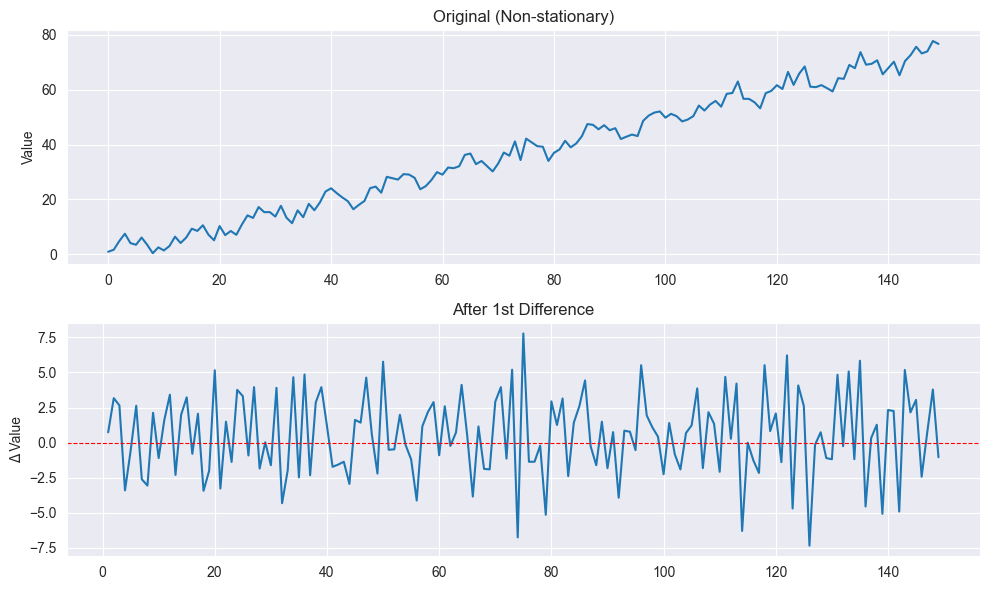

ADF Test: After 1st Difference
ADF Statistic: -8.1117
p-value: 0.0000
Critical Values:
  1%: -3.479
  5%: -2.883
  10%: -2.578
Reject H₀: Series is STATIONARY


1.2212397339380835e-12

In [106]:
##################################
# Check stationarity with ADF test
##################################

from statsmodels.tsa.stattools import adfuller

def adf_test(series, name=""):
    result = adfuller(series.dropna())
    print(f"ADF Test: {name}")
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"p-value: {result[1]:.4f}")
    print(f"Critical Values:")
    for key, value in result[4].items():
        print(f"  {key}: {value:.3f}")

    if result[1] < 0.05:
        print("Reject H₀: Series is STATIONARY")
    else:
        print("Fail to reject H₀: Series is NON-STATIONARY")
    return result[1]

# Test original series
adf_test(pd.Series(ts_nonstationary), "Original Series")

################################
# Apply differencing and retest
################################

# First difference
ts_diff1 = pd.Series(ts_nonstationary).diff().dropna()

fig, axes = plt.subplots(2, 1, figsize=(10, 6))

axes[0].plot(ts_nonstationary)
axes[0].set_title("Original (Non-stationary)")
axes[0].set_ylabel("Value")

axes[1].plot(ts_diff1)
axes[1].set_title("After 1st Difference")
axes[1].set_ylabel("Δ Value")
axes[1].axhline(0, color='red', linestyle='--', linewidth=0.8)

plt.tight_layout()
plt.show()

# Test differenced series
adf_test(ts_diff1, "After 1st Difference")

2. **Identify $p$ and $q$:**
    - Plot ACF and PACF of differenced series
    - Determine candidate models
    - Try grid search

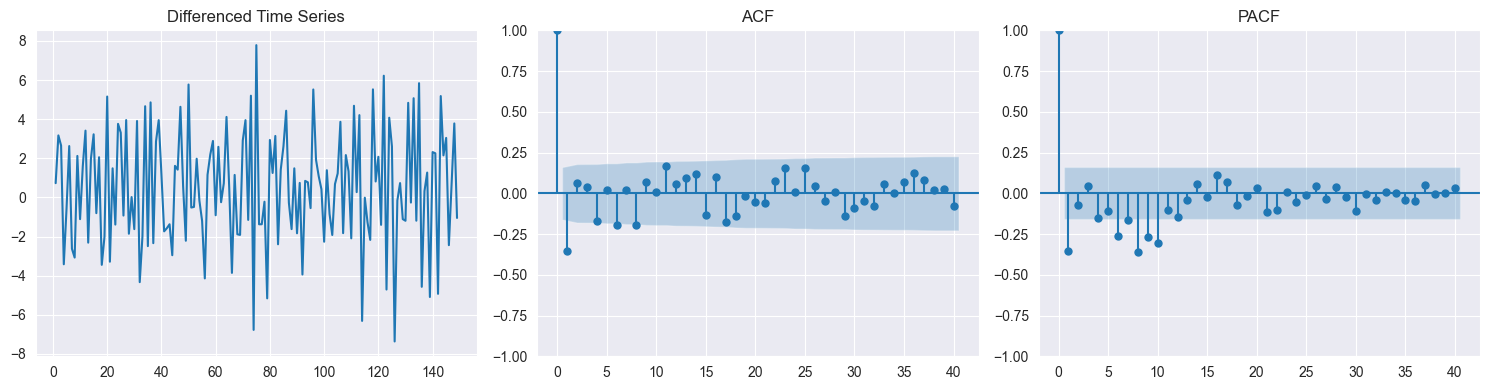

In [107]:
#########################################
# Plot ACF and PACF of differenced series
#########################################

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(ts_diff1)
axes[0].set_title("Differenced Time Series")

plot_acf(ts_diff1, lags=40, ax=axes[1])
axes[1].set_title("ACF")

plot_pacf(ts_diff1, lags=40, ax=axes[2])
axes[2].set_title("PACF")

plt.tight_layout()
plt.show()

3. **Estimate parameters:**
    - Fit candidate models
    - Use maximum likelihood

In [108]:
from statsmodels.tsa.arima.model import ARIMA

#########################
# Fit ARIMA(1,1,1) model
#########################
# ARIMA(1,1,1): AR(1) + 1 difference + MA(1)
model = ARIMA(ts_nonstationary, order=(1, 1, 1)).fit()
print(model.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  150
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -367.059
Date:                Wed, 28 Jan 2026   AIC                            740.119
Time:                        19:12:42   BIC                            749.130
Sample:                             0   HQIC                           743.780
                                - 150                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2920      0.261     -1.117      0.264      -0.804       0.220
ma.L1         -0.0205      0.274     -0.075      0.940      -0.557       0.516
sigma2         8.0720      1.205      6.699      0.0

4. **Diagnose:**
    - Check residuals (should be white noise)
    - ACF of residuals should be within confidence bands
    - Ljung-Box test

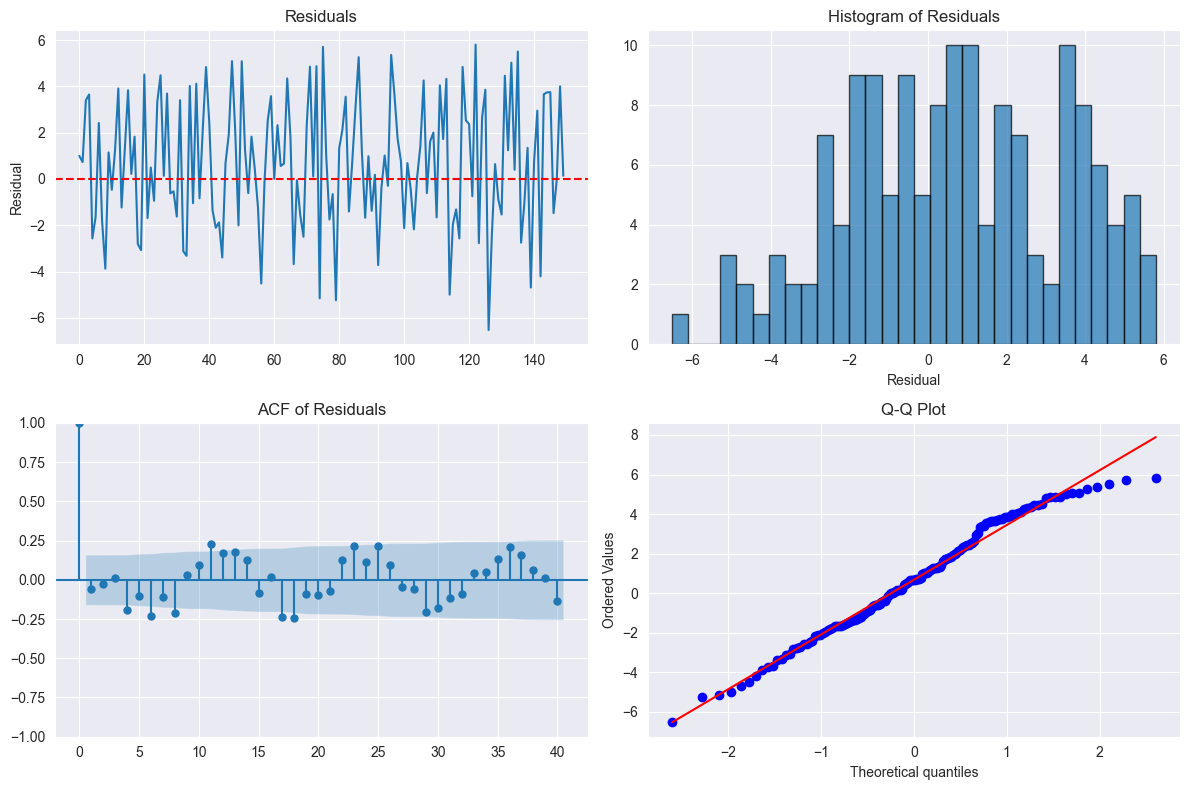

      lb_stat  lb_pvalue
1    0.577286   0.447378
2    0.676034   0.713183
3    0.689716   0.875620
4    6.361086   0.173756
5    8.017060   0.155298
6   16.240125   0.012522
7   18.111711   0.011476
8   25.348353   0.001357
9   25.472304   0.002491
10  27.015155   0.002590

If p-values > 0.05, residuals are white noise (good model fit)


In [109]:
from statsmodels.tsa.arima.model import ARIMA

# Use the fitted ARIMA(1,1,1) model
model = ARIMA(ts_nonstationary, order=(1, 1, 1)).fit()
residuals = model.resid

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Residuals plot
axes[0, 0].plot(residuals)
axes[0, 0].axhline(0, color='red', linestyle='--')
axes[0, 0].set_title("Residuals")
axes[0, 0].set_ylabel("Residual")

# Histogram
axes[0, 1].hist(residuals, bins=30, edgecolor='black', alpha=0.7)
axes[0, 1].set_title("Histogram of Residuals")
axes[0, 1].set_xlabel("Residual")

# ACF of residuals
plot_acf(residuals, lags=40, ax=axes[1, 0])
axes[1, 0].set_title("ACF of Residuals")

# Q-Q plot
from scipy import stats
stats.probplot(residuals, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title("Q-Q Plot")

plt.tight_layout()
plt.show()

#############################################
# Ljung-Box test for residual autocorrelation
#############################################

from statsmodels.stats.diagnostic import acorr_ljungbox

lb_test = acorr_ljungbox(residuals, lags=20, return_df=True)
print(lb_test.head(10))
print("\nIf p-values > 0.05, residuals are white noise (good model fit)")

5. **Select best model:**
    - Compare AIC or BIC
    - Choose simplest model with good fit

In [110]:
from statsmodels.tsa.arima.model import ARIMA

models = [
    (1, 1, 0),
    (1, 1, 1),
    (2, 1, 0),
    (0, 1, 1),
    (2, 1, 1),
    (1, 1, 2)
]

results = []
for order in models:
    try:
        model = ARIMA(ts_nonstationary, order=order)
        fitted = model.fit()
        results.append({
            'Order': f"ARIMA{order}",
            'AIC': fitted.aic,
            'BIC': fitted.bic,
            'Log-Likelihood': fitted.llf
        })
    except:
        pass

df_results = pd.DataFrame(results)
df_results = df_results.sort_values('AIC')
print(df_results.to_string(index=False))

print("\nBest model by AIC:", df_results.iloc[0]['Order'])
print("Best model by BIC:", df_results.sort_values('BIC').iloc[0]['Order'])

         Order        AIC        BIC  Log-Likelihood
ARIMA(1, 1, 0) 738.128061 744.135954     -367.064030
ARIMA(0, 1, 1) 739.573497 745.581390     -367.786749
ARIMA(2, 1, 0) 740.112690 749.124529     -367.056345
ARIMA(1, 1, 1) 740.118535 749.130373     -367.059267
ARIMA(1, 1, 2) 741.428986 753.444771     -366.714493
ARIMA(2, 1, 1) 742.119743 754.135528     -367.059871

Best model by AIC: ARIMA(1, 1, 0)
Best model by BIC: ARIMA(1, 1, 0)


/Users/marbetschar/Development/marbetschar/notes/.venv/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/Users/marbetschar/Development/marbetschar/notes/.venv/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'



6. **Forecast:**
    - Use selected model for prediction

### Forecasting with AR($p$)

**$k$-step Ahead Forecast:**
$\hat X_{n+k} = E[X_{n+k} \mid X_1, X_2, \dots, X_n]$

**Principle:**

- Replace future $X_{n+j}$ with forecasts $\hat X_{n+j}$
- Replace future $W_{n+j}$ with their expectation (zero)

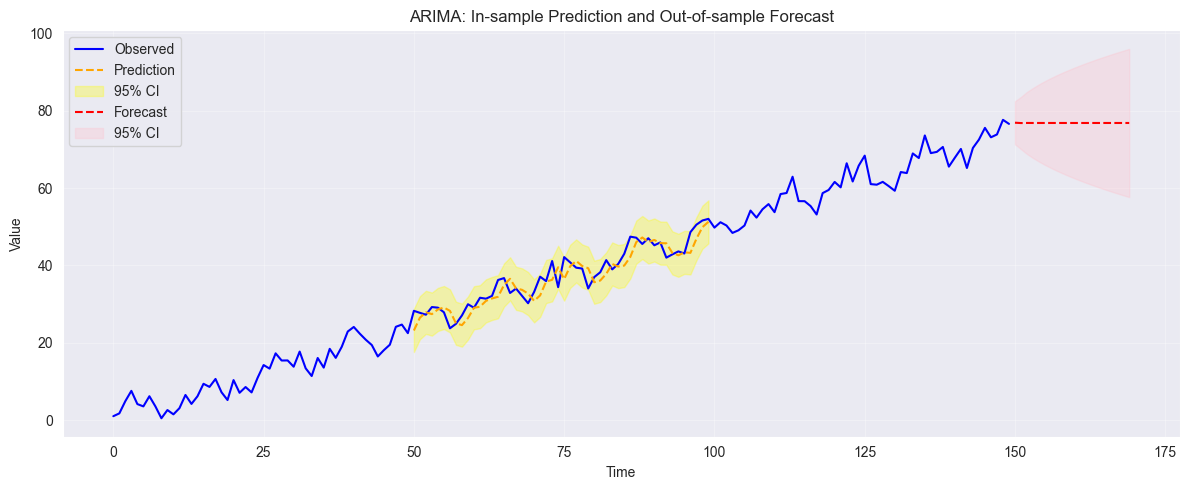

In [111]:
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(ts_nonstationary, order=(1, 1, 1)).fit()

# Forecast next 20 steps
forecast_steps = 20
forecast = model.get_forecast(steps=forecast_steps)
forecast_ci = pd.DataFrame(forecast.conf_int())

# Predict 50-100
prediction_start = 50
prediction_end = 100
prediction = model.get_prediction(start=prediction_start, end=prediction_end - 1)
prediction_ci = pd.DataFrame(prediction.conf_int())

######
# Plot
######
plt.figure(figsize=(12, 5))
plt.plot(ts_nonstationary, label="Observed", color='blue')

# In-sample Prediction
plt.plot(
    range(prediction_start, prediction_end),
    prediction.predicted_mean,
    label='Prediction',
    color='orange',
    linestyle='--')
plt.fill_between(
    range(prediction_start, prediction_end),
    prediction_ci.iloc[:, 0],
    prediction_ci.iloc[:, 1],
    color='yellow',
    alpha=0.3,
    label='95% CI')

# Out-of-sample Forecast
forecast_index = np.arange(len(ts_nonstationary), len(ts_nonstationary) + forecast_steps)
plt.plot(forecast_index, forecast.predicted_mean, label="Forecast", color='red', linestyle='--')
plt.fill_between(forecast_index,
                 forecast_ci.iloc[:, 0],
                 forecast_ci.iloc[:, 1],
                 color='pink', alpha=0.3, label='95% CI')
plt.legend()
plt.title("ARIMA: In-sample Prediction and Out-of-sample Forecast")
plt.xlabel("Time")
plt.ylabel("Value")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**AR(1) Forecasting:**

- 1-step: $\hat X_{n+1} = a X_n$
- 2-step: $\hat X_{n+2} = a \hat X_{n+1} = a^2 X_n$
- $k$-step: $\hat X_{n+k} = a^k X_n$

**AR($p$) Forecasting:**

- 1-step: $\hat X_{n+1} = a_1 X_n + a_2 X_{n-1} + \dots + a_p X_{n-p+1}$
- $k$-step: Use recursive substitution

**Long-Term Behavior:**

- For stationary AR: $\hat X_{n+k} \to \mu$ (mean) as $k \to \infty$
- Forecasts converge to unconditional mean
- Can only predict short-term structure

**Forecast Standard Error:**

- $\sigma_k = \sqrt{\operatorname{Var}(X_{n+k} - \hat X_{n+k})}$
- $\sigma_k$ increases with $k$
- $\sigma_k \to \sqrt{\operatorname{Var}(X_n)}$ as $k \to \infty$

**Confidence Intervals:**

- 95% CI: $\hat X_{n+k} \pm 1.96 \sigma_k$
- Widen as $k$ increases
- Eventually cover entire range of process

### SARIMA Models

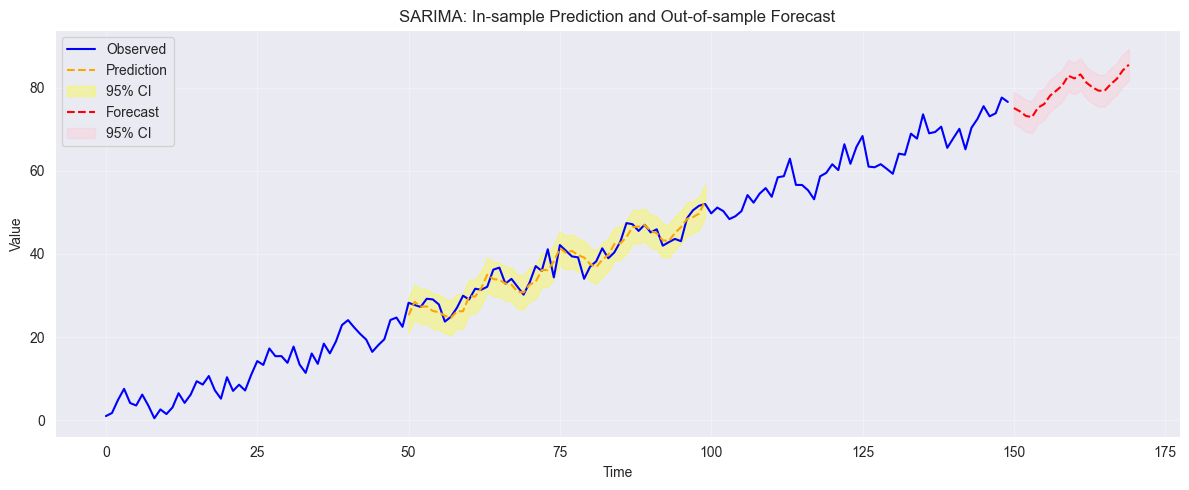

In [112]:
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Fit SARIMA
model = SARIMAX(ts_nonstationary, order=(1,1,1), seasonal_order=(1,1,1,12))
model = model.fit(disp=False)

# Forecast next 20 steps
forecast_steps = 20
forecast = model.get_forecast(steps=forecast_steps)
forecast_ci = pd.DataFrame(forecast.conf_int())

# Predict 50-100
prediction_start = 50
prediction_end = 100
prediction = model.get_prediction(start=prediction_start, end=prediction_end - 1)
prediction_ci = pd.DataFrame(prediction.conf_int())

######
# Plot
######
plt.figure(figsize=(12, 5))
plt.plot(ts_nonstationary, label="Observed", color='blue')

# In-sample Prediction
plt.plot(
    range(prediction_start, prediction_end),
    prediction.predicted_mean,
    label='Prediction',
    color='orange',
    linestyle='--')
plt.fill_between(
    range(prediction_start, prediction_end),
    prediction_ci.iloc[:, 0],
    prediction_ci.iloc[:, 1],
    color='yellow',
    alpha=0.3,
    label='95% CI')

# Out-of-sample Forecast
forecast_index = np.arange(len(ts_nonstationary), len(ts_nonstationary) + forecast_steps)
plt.plot(forecast_index, forecast.predicted_mean, label="Forecast", color='red', linestyle='--')
plt.fill_between(forecast_index,
                 forecast_ci.iloc[:, 0],
                 forecast_ci.iloc[:, 1],
                 color='pink', alpha=0.3, label='95% CI')
plt.legend()
plt.title("SARIMA: In-sample Prediction and Out-of-sample Forecast")
plt.xlabel("Time")
plt.ylabel("Value")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Purpose:** Model series with seasonality

**SARIMA($p,d,q)\times(P,D,Q)_s$:**

- $(p,d,q)$: non-seasonal part
- $(P,D,Q)_s$: seasonal part
- $s$: seasonal period (e.g., 12 for monthly, 4 for quarterly)

**Full Model:**
$\Phi(B^s)\,\varphi(B)\,\nabla_s^D \nabla^d X_n = \Theta(B^s)\,\theta(B)\,W_n$

**Components:**

- $\varphi(B) = 1 - a_1 B - \dots - a_p B^p$: non-seasonal AR
- $\Phi(B^s) = 1 - A_1 B^s - \dots - A_P B^{Ps}$: seasonal AR
- $\theta(B) = 1 + b_1 B + \dots + b_q B^q$: non-seasonal MA
- $\Theta(B^s) = 1 + B_1 B^s + \dots + B_Q B^{Qs}$: seasonal MA
- $\nabla^d = (1 - B)^d$: non-seasonal differencing
- $\nabla_s^D = (1 - B^s)^D$: seasonal differencing

**Example: SARIMA($0,0,1)\times(0,0,1)_{12}$**

- $(1 + b_1 B)(1 + B_1 B^{12}) X_n = W_n$
- $X_n = W_n + b_1 W_{n-1} + B_1 W_{n-12} + b_1 B_1 W_{n-13}$

**Common Models:**

- **SARIMA($0,1,1)\times(0,1,1)_{12}$:** Airline model (classic for seasonal data)
- **SARIMA($1,0,0)\times(1,0,0)_{12}$:** Pure seasonal AR

**Model Selection:**

- Look for seasonal spikes in ACF/PACF at lags $s, 2s, 3s, \dots$
- Try grid search over $(P,D,Q)$
- Use AIC/BIC to compare models

### Performance Metrics for Time Series

In [113]:
import numpy as np
from statsmodels.tsa.arima.model import ARIMA

np.random.seed(42)

# Generate time series with trend and seasonality
n = 150
time = np.arange(n)
trend = 0.3 * time
seasonal = 5 * np.sin(2 * np.pi * time / 12)
noise = np.random.normal(scale=2, size=n)
y = 50 + trend + seasonal + noise

# Train-test split
train_size = 120
train = y[:train_size]
test = y[train_size:]

# Fit ARIMA model
model = ARIMA(train, order=(1, 1, 1)).fit()

# Forecast
forecast = model.forecast(steps=len(test))

print(f"Train size: {len(train)}")
print(f"Test size: {len(test)}")
print(f"Forecast shape: {forecast.shape}")

Train size: 120
Test size: 30
Forecast shape: (30,)


**Mean Absolute Error (MAE):** $\text{MAE} = \dfrac{1}{n} \sum_{i=1}^n \lvert y_i - \hat y_i \rvert$



In [114]:
from sklearn.metrics import mean_absolute_error
mean_absolute_error(test, forecast)

6.433608462087063



- Average absolute forecast error
- Units of original data
- Robust to outliers
- Minimizing MAE → forecast median

**Root Mean Squared Error (RMSE):** $\text{RMSE} = \sqrt{\dfrac{1}{n} \sum_{i=1}^n (y_i - \hat y_i)^2}$

In [115]:
from sklearn.metrics import mean_squared_error
np.sqrt(mean_squared_error(test, forecast))

7.777461141918905

- Square root of average squared error
- Units of original data
- Penalizes large errors more than MAE
- More sensitive to outliers
- Minimizing RMSE → forecast mean

**Mean Absolute Percentage Error (MAPE):**
$\text{MAPE} = \dfrac{100}{n} \sum_{i=1}^n \dfrac{\lvert y_i - \hat y_i \rvert}{\lvert y_i \rvert}$

In [116]:
from sklearn.metrics import mean_absolute_percentage_error
mape = mean_absolute_percentage_error(test, forecast) * 100

if mape < 10:
    print(f"Excellent forecast; MAPE = {mape}")
elif mape < 20:
    print(f"Good forecast; MAPE = {mape}")
elif mape < 50:
    print(f"Reasonable forecast; MAPE = {mape}")
else:
    print(f"Poor forecast; MAPE = {mape}")

Excellent forecast; MAPE = 6.8575562666930905












- Average absolute percentage error
- Scale-independent (can compare across series)
- **Problem:** Undefined if $y_i = 0$, extreme if $y_i \approx 0$

**Which to Use:**

- MAE: Simple, interpretable, robust
- RMSE: Standard in many fields, penalizes large errors
- MAPE: Compare across different scales
- All should be computed on test set (out-of-sample)!

In [117]:
from sklearn.metrics import (mean_squared_error, mean_absolute_error,
                             mean_absolute_percentage_error, r2_score)

def evaluate_forecast(y_true, y_pred, model_name="Model"):
    """Calculate all performance metrics"""
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    r2 = r2_score(y_true, y_pred)

    print(f"Performance Metrics: {model_name}")
    print(f"MSE:    {mse:.4f}")
    print(f"RMSE:   {rmse:.4f}")
    print(f"MAE:    {mae:.4f}")
    print(f"MAPE:   {mape:.2f}%")
    print(f"R²:     {r2:.4f}")

    return {
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'MAPE': mape,
        'R2': r2
    }

# Evaluate
metrics = evaluate_forecast(test, forecast, "ARIMA(1,1,1)")

Performance Metrics: ARIMA(1,1,1)
MSE:    60.4889
RMSE:   7.7775
MAE:    6.4336
MAPE:   6.86%
R²:     -1.5123


## Spectral Analysis (Brief Overview)

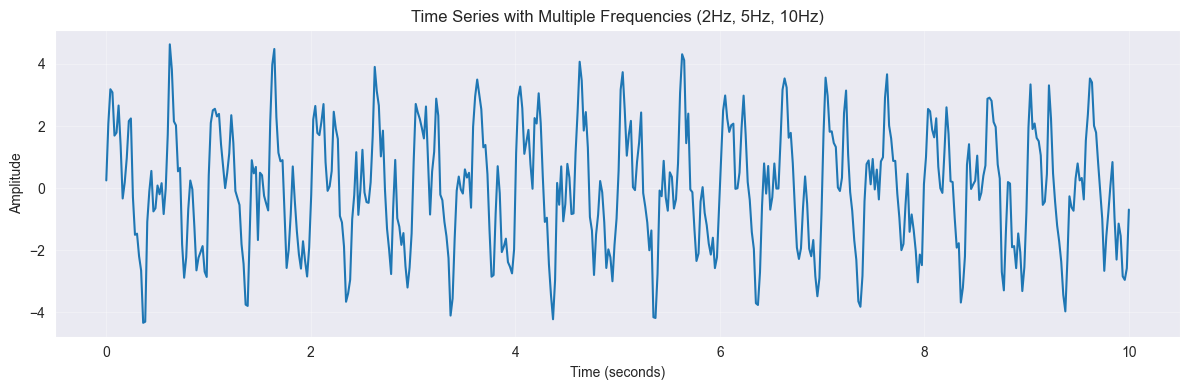

In [118]:
import numpy as np
import matplotlib.pyplot as plt

# Create signal with multiple frequencies
np.random.seed(42)
n = 500
t = np.linspace(0, 10, n)

# Signal = sum of sine waves at different frequencies
f1, f2, f3 = 2, 5, 10  # Hz
signal = (2 * np.sin(2 * np.pi * f1 * t) +
          1.5 * np.sin(2 * np.pi * f2 * t) +
          0.8 * np.sin(2 * np.pi * f3 * t) +
          np.random.normal(scale=0.5, size=n))

plt.figure(figsize=(12, 4))
plt.plot(t, signal)
plt.title('Time Series with Multiple Frequencies (2Hz, 5Hz, 10Hz)')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Fourier Series

**Purpose:** Decompose periodic function into sum of sines and cosines

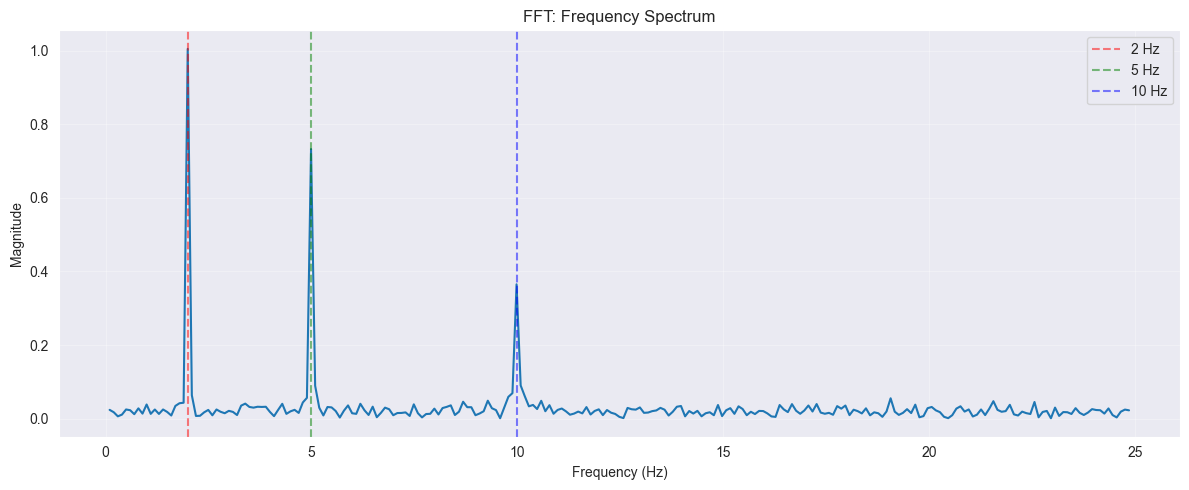

In [119]:
import numpy as np

# Compute FFT
fft = np.fft.fft(signal) / len(signal)
fft_freq = np.fft.fftfreq(len(signal), d=(t[1]-t[0]))

# Get magnitude (power)
fft_magnitude = np.abs(fft)

# Plot only positive frequencies
positive_freq_idx = fft_freq > 0

plt.figure(figsize=(12, 5))
plt.plot(fft_freq[positive_freq_idx], fft_magnitude[positive_freq_idx])
plt.title('FFT: Frequency Spectrum')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.grid(alpha=0.3)
plt.axvline(f1, color='red', linestyle='--', alpha=0.5, label='2 Hz')
plt.axvline(f2, color='green', linestyle='--', alpha=0.5, label='5 Hz')
plt.axvline(f3, color='blue', linestyle='--', alpha=0.5, label='10 Hz')
plt.legend()
plt.tight_layout()
plt.show()

**Fourier Series (period $T$):**
$f(t) = a_0/2 + \sum_{k=1}^\infty \left[a_k \cos\left(\dfrac{2\pi k t}{T}\right) + b_k \sin\left(\dfrac{2\pi k t}{T}\right)\right]$

**Fourier Coefficients:**

- $a_0 = \dfrac{2}{T} \int_0^T f(t)\,dt$ (average value)
- $a_k = \dfrac{2}{T} \int_0^T f(t)\cos\left(\dfrac{2\pi k t}{T}\right)\,dt$
- $b_k = \dfrac{2}{T} \int_0^T f(t)\sin\left(\dfrac{2\pi k t}{T}\right)\,dt$

**Interpretation:**

- Each term represents harmonic at frequency $k/T$
- Coefficients $a_k, b_k$ show strength of each frequency


### Discrete Fourier Transform (DFT)

**For discrete series $x_0, x_1, \dots, x_{n-1}$:**
$X_k = \sum_{j=0}^{n-1} x_j e^{-2\pi i j k / n}, \quad k = 0,1,\dots,n-1$

**FFT (Fast Fourier Transform):**

- Efficient algorithm for computing DFT
- Complexity: $O(n \log n)$ instead of $O(n^2)$
- Standard in practice







**Power Spectrum (Periodogram):**

- $I_k = |X_k|^2 / n$
- Shows strength of each frequency component
- Peak at frequency $f$ → periodic component with period $1/f$


### Spectral Density

**Continuous Spectrum:**

- $f(\omega)$: spectral density function
- Related to autocovariance via Fourier transform
- $f(\omega) = \dfrac{1}{2\pi} \sum_{h=-\infty}^{\infty} \gamma(h) e^{-i \omega h}$

**Properties:**

- White noise: flat spectrum (all frequencies equal)
- AR/MA: smooth spectrum with peaks/troughs
- Strong peak at $\omega$ → dominant periodic component

**Use in Practice:**

- Identify dominant frequencies (periodicities)
- Compare models (theoretical vs empirical spectrum)
- Detect hidden periodic components